## Module 4: Cancer

## Team Members: Will Marschall and Dani Folks

## Project Title: Do proliferative-signaling and apoptosis-evasion expression programs track tumor stage in colon adenocarcinoma?



## Project Goal: 

Our project seeks to determine whether two cancer hallmarks (**sustained proliferative signaling** and **resisting apoptosis**) show coordinated RNA-expression patterns in **colon adenocarcinoma (COAD)** and whether those patterns may relate to tumor stage.

Our current working hypothesis is that **COAD tumors with higher expression of proliferative-signaling genes will also show stronger apoptosis-resistance patterns and will tend to fall into more advanced tumor-stage groups**, although this remains a hypothesis to be tested over Module 4 rather than a conclusion.

## Disease Background:

### Cancer hallmark focus
For this project, we decided to focus in on two hallmarks that are mechanistically connected and also easy to operationalize with our RNA-expression data:

1. **Sustained growth/proliferative signaling**  
   In our quick reference handout, we saw that this hallmark is described as cancer cells no longer waiting for normal external growth signals before dividing. This hallmark increases the cancer-cell division rate and relates idea to overactive growth-factor receptors and downstream signaling genes such as **EGFR, RAS/KRAS, BRAF, and MYC** [1].
   In healthy tissue, proliferation is tightly regulated by extracellular ligands (e.g., growth factors) binding to receptors, which activate intracellular signaling cascades only when appropriate. In cancer, this control is bypassed through multiple mechanisms that lead to constitutive activation of growth pathways, including:

   - Overexpression or mutation of receptor tyrosine kinases (e.g., EGFR, ERBB2), allowing signaling even in the absence of ligand
   - Activating mutations in downstream signaling proteins (e.g., KRAS, NRAS, BRAF), which lock pathways such as the MAPK/ERK cascade in an “on” state
   - Activation of survival and growth pathways such as PI3K/AKT signaling, promoting both proliferation and metabolic support
   - Upregulation of transcription factors (e.g., MYC, FOS, JUN) that directly increase expression of genes required for cell-cycle progression

2. **Resist apoptosis**  
   This hallmark describes the ability of cancer cells to evade/resist programmed cell death, a tightly regulated process that normally removes damaged or abnormal cells. In healthy tissue, apoptosis is particularly triggered by DNA damage, oncogenic stress, or loss of survival signals, and is executed through coordinated activation of caspases via intrinsic (mitochondrial) and extrinsic (death-receptor) pathways. For this project, our apoptosis-resistance genes includes **TP53, BCL2, BCL2L1, MCL1, CASP8, CASP3, BAX, BAK1, APAF1, BID, CASP9, FAS, FASLG, BAD, BBC3, BCL2L11, CFLAR, DIABLO, TNF, and TNFRSF10B.** In cancer, this system is disrupted through multiple mechanisms which include: 
   - Upregulation of anti-apoptotic proteins **(e.g., BCL2, BCL2L1, MCL1)**, which stabilize mitochondrial membranes and prevent cytochrome c release 
   - Downregulation or mutation of pro-apoptotic factors **(e.g., BAX, BAK1, BID)** 
   - Loss of tumor suppressor function, especially **TP53**, which we assume would normally promote apoptosis in response to DNA damage
   - Impaired caspase activation, limiting execution of the apoptotic program

   In a functional sense, resisting apoptosis allows cancer cells to survive despite accumulating mutations as well as sustain growth under stress (and during therapy). 

### Why we chose colon adenocarcinoma (COAD)
We narrowed our analysis to **one cancer type** instead of many because we were contemplated on deciding whether to focus on one cancer type or to compare multiple cancers, and a single-type analysis is less biologically heterogeneous for our machine-learning workflow discussed in depth during class. We chose **colon adenocarcinoma (COAD)** because:
- Colorectal cancer was emphasized in our 1st lecture and hallmark simulation discussion
- Colon cancer has well-established links to deregulated growth signaling pathways
- Stage information is clinically meaningful for this disease in our initial examination
- One cancer type is a cleaner starting point than attempting many tumor biologies on an initial workflow.
- Colorectal cancer is one of the most common cancers worldwide, ranking third in incidence globally and contributing substantially to cancer-related mortality. [5] 
This provides us with a strong ethical and scientific motivation to further investigate COAD due to the large number of individuals it affects. 

### Overview of hallmark biology
In normal tissues, cells only divide when instructed by extracellular signals, undergo apoptosis when damaged or no longer needed, and remain integrated within the structural and functional organization of the tissue. These processes are largely controlled through coordinated signaling networks that maintain tissue homeostasis and also balance cell proliferation with differentiation and death. Cancer can be easily understood as the breakdown of these regulatory systems, where cells progressively acquire the ability to override multiple biological constraints at the same time. Rather than a single mutation causing disease, tumor development illustrates how the accumulation of changes disrupting normal control mechanisms can allow cells to behave in an erratic manner.

For this project, we focus on two complementary hallmarks: one that acts as the “gas pedal” by driving sustained cell division, and one that weakens the “brake pedal” by impairing programmed cell death, the same analogy used in class to distinguish between oncogenes and tumor suppressors. Together, these hallmarks help us define a two-axis framework in which tumors can be positioned based on how strongly they promote growth versus how effectively they evade death. This paired analysis provides a biologically interpretable way to assess tumor behavior using our provided RNA-expression data.

### Genes associated with the hallmark to be studied
We expanded our hallmark panel to 40 genes total so that the model has a richer feature space while remaining biologically interpretable.

**Sustained proliferative signaling genes**
`EGFR, ERBB2, KRAS, NRAS, BRAF, PIK3CA, AKT1, MYC, FOS, JUN, MET, IGF1R, FGFR1, FGFR2, EGF, HGF, SOS1, GRB2, MAPK1, MAPK3`

These genes span multiple levels of growth signaling pathways, including:

- Receptor-level activation (EGFR, ERBB2)

- Intracellular signal transduction (KRAS, NRAS, BRAF, PIK3CA, AKT1)

- Transcriptional regulation of the cell cycle (MYC, FOS, JUN)

**Resist apoptosis genes**
`TP53, BCL2, BCL2L1, MCL1, CASP8, CASP3, BAX, BAK1, APAF1, BID, CASP9, FAS, FASLG, BAD, BBC3, BCL2L11, CFLAR, DIABLO, TNF, TNFRSF10B`

These genes represent key regulators of apoptotic pathways, including:

- Tumor suppressor signaling (TP53)

- Mitochondrial apoptosis regulation (BCL2 family: BCL2, BCL2L1, MCL1, BAX, BAK1, BID)

- Execution of apoptosis via caspases (CASP8, CASP3)

- Apoptosome formation and signaling (APAF1)

A CSV version of our list is included in our repo as `hallmark_gene_sets.csv`. In the EDA step, we explicitly check which of these genes are present in the local training matrix before making any downstream claims.

### Prevalence & incidence
Colorectal cancer is a major public-health burden. The American Cancer Society estimates that in the United States in **2026** there will be about **108,860 new colon cancer cases** and **49,990 new rectal cancer cases**, and colorectal cancer is expected to cause about **55,230 deaths**. Excluding skin cancers, it is the **third most common cancer** diagnosed in both men and women in the United States [5].

### Risk factors (genetic, lifestyle) & societal determinants
Major risk factors for colorectal cancer include **older age**, **family history**, **personal history of colorectal neoplasia**, inherited syndromes such as familial adenomatous polyposis **FAP** and **Lynch syndrome**. Lifestyle-related factors also play a role, including **dietary patterns**, **alcohol consumption**, **cigarette smoking**, and **obesity** [4], [5]. All of which can largely influence inflammation and cellular stress within the colon. **Inflammatory bowel disease (IBD)** further increases risk by repeated cycles of tissue damage and regeneration, which can faciliate mutation accumulation. 

In addition to biological risk factors, we note that societal determinants can significantly contribute to risk factors, including access to screening, healthcare availability, socioeconomic status, and geographic location—strongly influence both incidence and outcomes. Early detection can significantly reduce mortality by identifying precancerous lesions or early-stage tumors, whereas limited access to care is associated with later-stage diagnoses and poorer prognosis [5].

### Standard of care treatments (& reimbursement)
Treatment depends strongly on stage and biomarker status. For early-stage disease, surgical resection is often the primary treatment and can be curative. Standard approaches include **surgery**, **chemotherapy**, **radiation therapy** (more common in rectal disease), **targeted therapy**, and **immunotherapy**.

While we do not make detailed reimbursement claims in this analysis, it is important to note that both tumor stage and biomarker status directly influence treatment selection as well as eligibility for targeted therapies and overall cost of care. This further supports our emphasis on the relevance of linking molecular patterns—such as hallmark-associated gene expression—to clinically meaningful variables like tumor stage.

### Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)
The colon absorbs water and electrolytes from intestinal contents, while the rectum stores stool before elimination. Colon adenocarcinoma arises from epithelial cells in this system. At the molecular level, colorectal tumor development is driven by changes in genes controlling cell division, survival, differentiation, and tissue organization. That makes COAD a good test case for our RNA-based hallmark analysis because aberrant growth signaling and resistance to cell death should both leave measurable transcriptomic signatures for us to interpret [4].

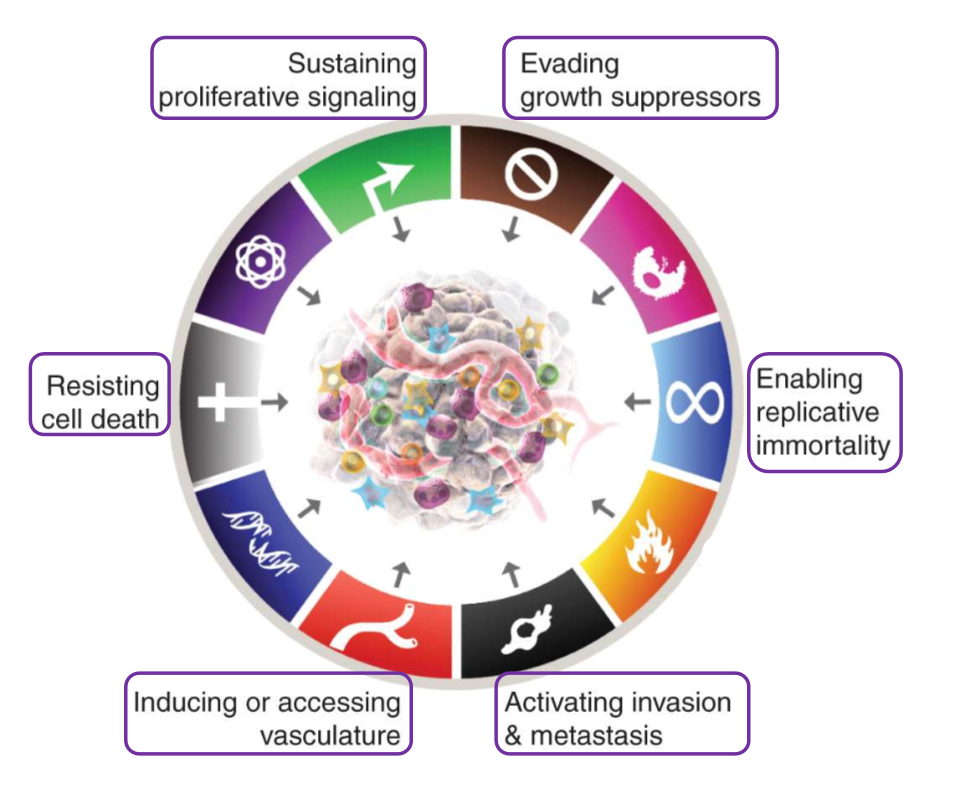


## Data-Set: 

The dataset for this project comes from **The Cancer Genome Atlas (TCGA) RNA-seq data reprocessed by Rahman et al.** and distributed through **GEO accession GSE62944** [2], [3]. Dr. Groves further subsetted those data to a smaller teaching dataset containing approximately **50–100 tumors per cancer type** across **24 cancer types** (about **1802 tumors total**) with a reduced metadata table. It should also be noted that not all metadata fields are populated equally across cancer types, so checking missingness is an explicit part of our EDA.

### What these files contain
- `TRAINING_SET_GSE62944_subsample_log2TPM.csv`  
  Gene-expression matrix with **genes as rows** and **tumor samples as columns**.
- `TRAINING_SET_GSE62944_metadata.csv`  
  Metadata table with **samples as rows** and clinical/annotation variables as columns.
- `VALIDATION_SET_...` and `TEST_SET_...`  
  These will be used later for model development/validation
- `GSE62944_metadata_percent_nonNA_by_cancer_type.csv`  
  An provided summary of metadata completeness by cancer type.

### What is RNA-seq and how should the values be interpreted?
RNA sequencing measures the abundance of RNA transcripts in a sample, which gives a snapshot of our **transcriptome**. In this dataset, the values are **log2(TPM + 1)**:
- **TPM** stands for **transcripts per million**, a normalization that accounts for gene length and sequencing depth.
- The **log2(TPM + 1)** transform compresses the dynamic range so highly expressed genes do not dominate as strongly and zero counts remain defined [2].

Because our dataset is already normalized and log-transformed, it is appropriate for exploratory plots, correlation analysis, and many machine-learning workflows. However, the expression values are **not raw counts**, so count-based methods like DESeq2 would require different input data.

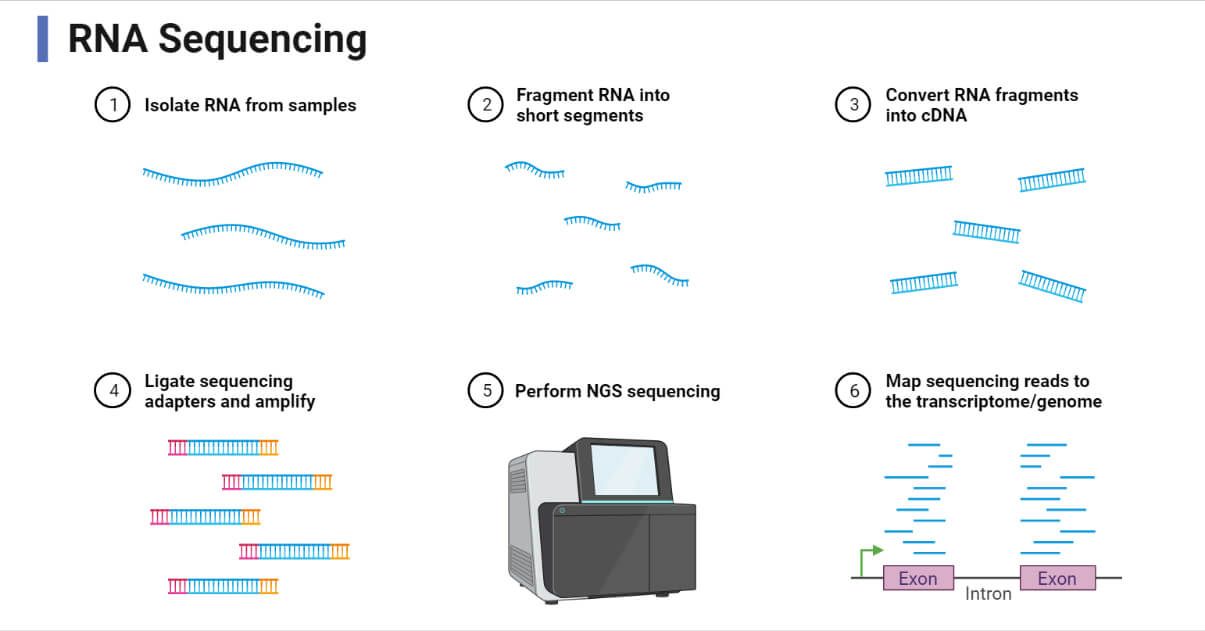

### How the data were generated
Rahman et al. describe reprocessing TCGA RNA-seq data using the **Rsubread** pipeline, aligning reads to the **hg19** reference genome, generating **gene-level integer counts** with `featureCounts`, and then converting those to normalized **FPKM** and **TPM** values. The GEO record states that the dataset contains **9264 tumor samples and 741 normal samples across 24 cancer types** in the full public compendium, along with matched clinical variables [3].

### Metadata we expect to use
The most important of our metadata fields are:
- `cancer_type` to isolate **COAD**
- a **tumor stage** field, if available/populated for COAD in the training split
- possibly age/sex or other basic covariates if available and relevant later on in our analysis

Because stage-column names can differ across datasets, our EDA script searches several likely stage-column names automatically instead of assuming one fixed label.

### What we do in the EDA
Our EDA script is designed to answer these questions:
- What is the size of the training matrix?
- What are the minimum, maximum, and average expression values?
- Which genes have the highest average expression?
- What metadata are missing?
- Are our hallmark genes actually in the dataset?
- How many COAD samples are in the training split?
- Can we visualize the two hallmark programs with scatterplots and PCA?




## Data Analysis: 

### Methods
We utilized **unsupervised learning** methods to explore structure in the COAD samples, following the dimensionality-reduction and clustering workflow introduced to us in detail lecture. We first cleaned the metadata by converting age to numeric and simplifying AJCC tumor-stage labels into broader **Stage I**, **Stage II**, **Stage III**, and **Stage IV** bins. We also created a binary stage label (E**arly = Stage I/II**, **Late = Stage III/IV)** for our future supervised-learning model.

We then subset the expression matrix to COAD and to a **40-gene hallmark panel**: **20 genes** associated with **sustained proliferative signaling** and **20 genes** associated with **resisting cell death**. Our resulting sample-by-gene matrix was standardized before machine learning so that genes with different expression ranges would contribute more comparably to our downstream analyses.

We used **PCA** as our first dimensionality-reduction method because it provides a linear summary of the strongest axes of variation in the selected hallmark genes. We then used **K-means clustering** to look for exploratory subgroups in the standardized gene-expression matrix. K-means minimizes the within-cluster distance between samples and their assigned centroids, so it provides us with a great and simple first pass at identifying molecular groupings. We evaluated candidate values of k from **2 to 6** using silhouette score and selected the **best-performing k**. We also used **UMAP** as a nonlinear dimensionality-reduction method to compare whether local neighborhood structure looked similar to our PCA view.

For our later supervised-learning analysis, our first-choice model will be **logistic regression** to classify simplified tumor stage (**Early vs. Late**) from the hallmark-expression features. This is a good first choice because our target is categorical, our sample size is modest, and logistic regression provides an interpretable baseline before trying more complex classifiers.

We moved from exploratory unsupervised analysis to supervised classification. More specifically, we used logistic regression to predict simplified tumor stage (**Early = Stage I/II, Late = Stage III/IV**) from hallmark-expression features in COAD. We chose logistic regression because our target is binary, our sample size is modest, and the method provides an interpretable baseline before trying more complex classifiers.

We trained the model using only the **training dataset** and then evaluated out-of-sample performance using only the **validation dataset**, as stated in class. We first built a **baseline model** using the 40 hallmark genes alone. We then made one deliberate model improvement by adding biologically meaningful summary features (**proliferative score**, **apoptosis-resistance score**, and **age at diagnosis**) and by using **class-weight balancing** with stronger regularization to reduce the effect of class imbalance and improve generalization.

To evaluate performance, we used both **threshold-dependent** and **threshold-independent** metrics. At the default threshold of 0.5, we reported **accuracy**, **balanced accuracy**, **precision**, **recall**, **F1 score**, and the **confusion matrix**. Across all thresholds, we reported **AUROC**, which is useful because logistic regression produces probability scores rather than only hard class labels. We compared in-sample performance on the training data to out-of-sample performance on the validation data to assess whether the model generalized or appeared to overfit.

### Analysis


#### 1. Set up the notebook and import our analysis script

In this first step, we set up the notebook environment and import our main.py script from the code folder. This lets us keep the full analysis logic in one reusable Python file while still showing the major workflow steps inside the notebook.

In [42]:
# This is a short snippet from our main.py script. 
# The full script is quite long, so we are only showing the top portion here where we set up the environment and import our custom main module.
# Please view our main.py script for full detailed comments, methodologies, and results.
from pathlib import Path
import sys
import importlib
import pandas as pd
from IPython.display import display, Image

pd.options.display.float_format = "{:.6f}".format

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name.lower() == "code" else NOTEBOOK_DIR
CODE_DIR = PROJECT_ROOT / "code"

if str(CODE_DIR) not in sys.path:
    sys.path.append(str(CODE_DIR))

import main
importlib.reload(main)

<module 'main' from 'e:\\OneDrive - University of Virginia\\Will M\\Undergraduate Research Courses-Grants\\05_Spring_2026\\Computational_Biomedical_BME_2315\\Module-4-Cancer\\code\\main.py'>

#### 2. Run the full exploratory workflow on the COAD training set

This cell runs the full exploratory workflow defined in `main.py`. It loads the training expression matrix and metadata, subsets the data to COAD, checks whether the selected hallmark genes are present, cleans the metadata, computes hallmark scores, performs PCA and K-means clustering, and generates the summary figures saved to the `results` folder.

Loaded expression data.
        TCGA-E9-A1NI-01A-11R-A14D-07  TCGA-E2-A1LK-01A-21R-A14D-07  \
A1BG                        3.397369                      3.466089   
A1CF                        0.008857                      0.039562   
A2M                         7.575125                      6.643613   
A2ML1                       0.397610                      7.625124   
A4GALT                      5.277425                      5.244677   

        TCGA-BH-A0B2-01A-11R-A10J-07  TCGA-E2-A107-01A-11R-A10J-07  \
A1BG                        3.789771                      3.967578   
A1CF                        0.065051                      0.000000   
A2M                         9.024479                      7.573842   
A2ML1                       0.428689                      0.465410   
A4GALT                      4.072650                      4.208381   

        TCGA-LL-A5YN-01A-11R-A28M-07  TCGA-BH-A0DQ-01A-11R-A084-07  \
A1BG                        4.733007                      3.0113

e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl


KMeans model selection summary:
   k     inertia  silhouette_score
0  2 2682.814190          0.150278
1  3 2411.957810          0.153595
2  4 2189.351156          0.103196
3  5 2057.638214          0.093785
4  6 1957.743396          0.086763

Best KMeans k based on silhouette score: 3 (silhouette = 0.154)

Copied metadata completeness table to results folder.


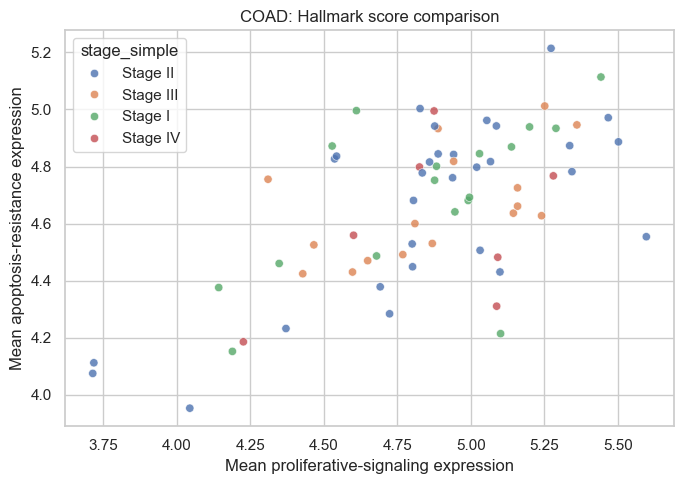

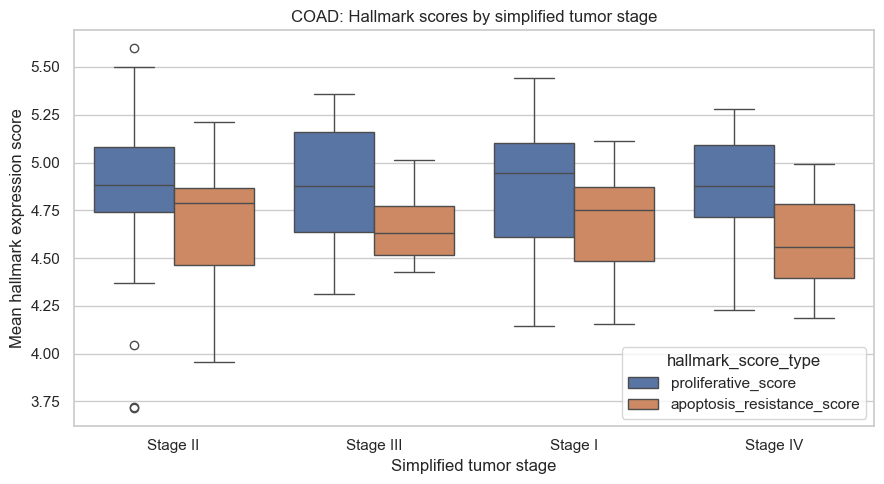

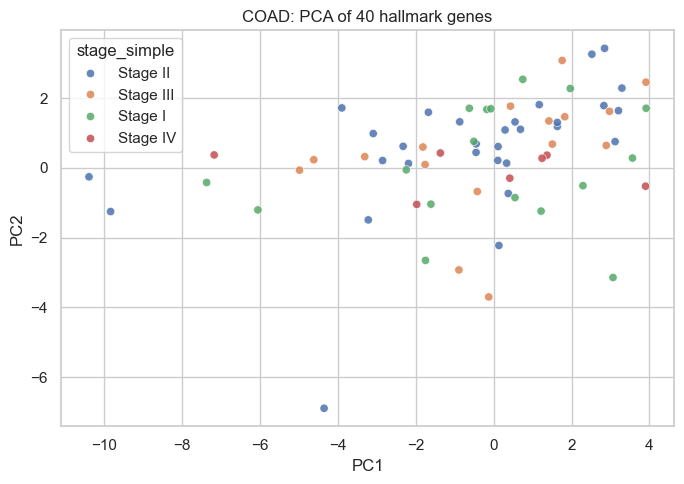

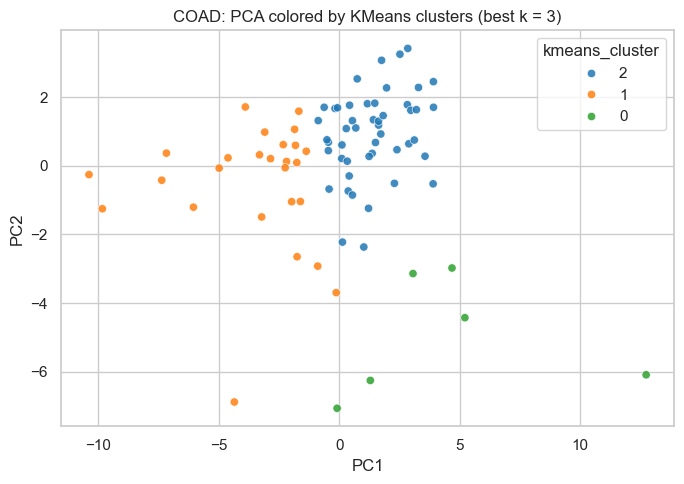

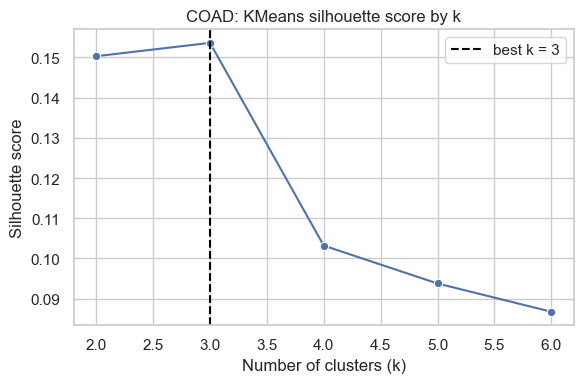

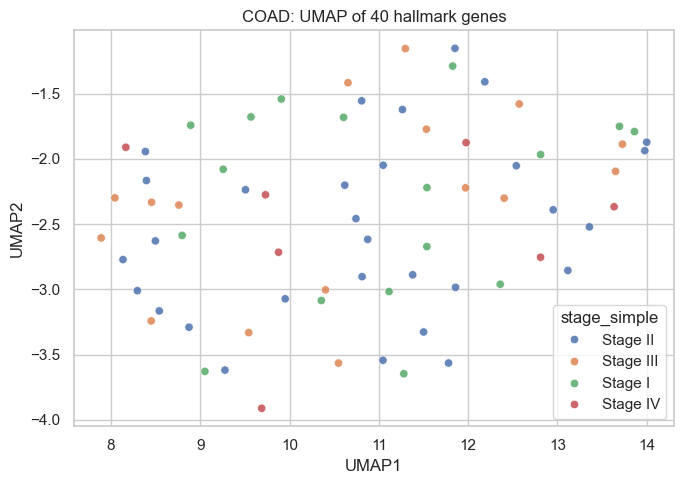

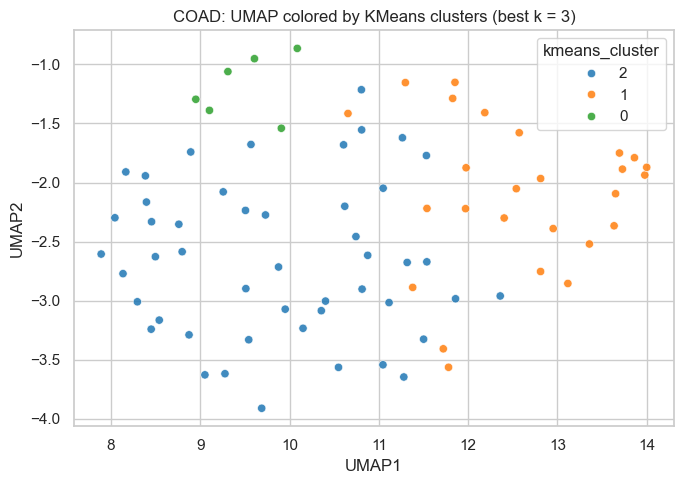


EDA complete. Results were saved to:
E:\OneDrive - University of Virginia\Will M\Undergraduate Research Courses-Grants\05_Spring_2026\Computational_Biomedical_BME_2315\Module-4-Cancer\results


In [43]:
# We wrap the entire EDA workflow in a function and call it in the main block.
# This shows our entire EDA workflow in one place and allows us to easily reuse the function in the notebook without needing to copy/paste code or reload data.
eda_outputs = main.run_eda()

#### 3. Display the global training-set summary

These outputs summarize our overall training expression matrix before subsetting to COAD. The first table reports the total number of genes and samples as well as the global minimum, maximum, mean, and median log2(TPM+1) expression values. The second table lists the genes with the highest average expression across the entire training set, which helps us understand the overall scale and composition of the dataset before narrowing to our hallmark-focused analysis.

In [44]:
# After running the EDA workflow, we can access all the major tables and results from the returned dictionary.
display(eda_outputs["full_summary"])

# For example, we can display the top mean expression table which shows the top 10 genes with the highest mean expression across all samples.
display(eda_outputs["top_mean_expression"])

,n_genes,n_samples,global_min_log2TPMplus1,global_max_log2TPMplus1,global_mean_log2TPMplus1,global_median_log2TPMplus1
0,15716,1802,0.000000,17.410280,3.716808,3.809865


,mean_expression
ACTB,12.594034
FTL,12.525603
TPT1,12.476975
B2M,12.347839
GAPDH,12.160252
TMSB10,11.998153
RPS11,11.933026
ACTG1,11.866736
RPS6,11.836285
RPL8,11.655261


#### 4. Examine metadata completeness and the cleaned COAD metadata

Because metadata completeness varies across cancer types in this teaching dataset, we explicitly examined missingness before moving forward. We also displayed the cleaned COAD metadata to confirm that age was converted to numeric where possible and that the detailed AJCC labels were successfully simplified into broader stage groups. This cleaning step is important because it prepares a more interpretable stage variable for plotting now and for supervised learning later.

In [45]:
# We can also display the missingness table which shows the percentage of missing values for each column in the dataset
# also the cleaned cancer metadata with the new stage columns we created.
display(eda_outputs["missingness"].head(20))

# Display the first 10 rows of the cleaned cancer metadata with the new stage columns we created.
display(
    eda_outputs["cancer_metadata"][
        ["age_at_diagnosis", "stage_clean", "stage_simple", "stage_binary"]
    ].head(10)
)

,n_non_missing,n_missing,percent_non_missing,percent_missing
cancer_type,1802,0,100.000000,0.000000
history_other_malignancy,1730,72,96.004440,3.995560
gender,1730,72,96.004440,3.995560
race,1730,72,96.004440,3.995560
ethnicity,1730,72,96.004440,3.995560
age_at_diagnosis,1730,72,96.004440,3.995560
bcr_patient_barcode,1730,72,96.004440,3.995560
OS,1727,75,95.837958,4.162042
OS.time,1719,83,95.394007,4.605993
tumor_status,1650,152,91.564928,8.435072


,age_at_diagnosis,stage_clean,stage_simple,stage_binary
sample,,,,
TCGA-AA-3532-01A-01R-0821-07,63.000000,Stage IIA,Stage II,Early
TCGA-AA-3842-01A-01R-1022-07,51.000000,Stage IIIA,Stage III,Late
TCGA-G4-6310-01A-11R-1723-07,69.000000,Stage IIIB,Stage III,Late
TCGA-AA-3975-01A-01R-1022-07,80.000000,Stage I,Stage I,Early
TCGA-AM-5820-01A-01R-1653-07,59.000000,Stage IVA,Stage IV,Late
TCGA-AA-A02W-01A-01R-A00A-07,73.000000,Stage I,Stage I,Early
TCGA-CA-6719-01A-11R-1839-07,77.000000,Stage IIA,Stage II,Early
TCGA-G4-6295-01A-11R-1723-07,70.000000,Stage II,Stage II,Early
TCGA-AA-3949-01A-01R-1022-07,87.000000,Stage IIIB,Stage III,Late


#### 5. Confirm that the selected hallmark genes are present in the COAD subset

Before interpreting any downstream result, we verified that the requested hallmark genes were actually present in the local expression matrix. The presence table confirms which genes were found, and the summary-statistics table provides the mean, median, and variance of each hallmark gene across the COAD samples. This step ensures that the selected features are available and gives a first look at which genes are relatively stable or variable within this cohort.

In [46]:
# Finally, we can also display the hallmark gene presence table which shows the presence/absence of hallmark genes in our dataset
# Also the summary statistics for these genes.
display(eda_outputs["hallmark_gene_presence"])
display(eda_outputs["hallmark_gene_stats"])

,hallmark,gene,present_in_dataset
0,Sustained_Proliferative_Signaling,EGFR,True
1,Sustained_Proliferative_Signaling,ERBB2,True
2,Sustained_Proliferative_Signaling,KRAS,True
3,Sustained_Proliferative_Signaling,NRAS,True
4,Sustained_Proliferative_Signaling,BRAF,True
5,Sustained_Proliferative_Signaling,PIK3CA,True
6,Sustained_Proliferative_Signaling,AKT1,True
7,Sustained_Proliferative_Signaling,MYC,True
8,Sustained_Proliferative_Signaling,FOS,True
9,Sustained_Proliferative_Signaling,JUN,True


,mean_expression,median_expression,variance_across_samples
MYC,8.228511,8.221083,0.659806
FOS,7.957519,7.856431,1.629929
JUN,7.618991,7.732972,0.609185
MCL1,7.431396,7.501133,0.490321
BCL2L1,7.398317,7.387813,0.527915
MAPK3,7.251998,7.294059,0.606089
BAX,7.229717,7.268432,0.492506
AKT1,7.080532,7.166449,0.234295
GRB2,6.810953,6.816642,0.198127
ERBB2,6.782761,6.903818,0.675691


#### 6. Review the sample-level hallmark-score table

We next computed one simple score per hallmark by averaging expression across the genes in each hallmark set for each sample. These sample-level hallmark scores give us a compact way to compare the two biological programs across tumors and provide a natural bridge between gene-level data and stage-based comparisons.

In [47]:
# We can also display the merged scores table which shows the proliferative score and apoptosis resistance score for each sample along with the stage information.
display(
    eda_outputs["merged_scores"][
        ["proliferative_score", "apoptosis_resistance_score", "stage_simple", "stage_binary"]
    ].head(10)
)

,proliferative_score,apoptosis_resistance_score,stage_simple,stage_binary
TCGA-AA-3532-01A-01R-0821-07,4.805219,4.681239,Stage II,Early
TCGA-AA-3842-01A-01R-1022-07,4.869162,4.530510,Stage III,Late
TCGA-G4-6310-01A-11R-1723-07,5.144955,4.636565,Stage III,Late
TCGA-AA-3975-01A-01R-1022-07,4.991320,4.681024,Stage I,Early
TCGA-AM-5820-01A-01R-1653-07,5.280900,4.767320,Stage IV,Late
TCGA-AA-A02W-01A-01R-A00A-07,5.101496,4.214700,Stage I,Early
TCGA-CA-6719-01A-11R-1839-07,5.597140,4.554142,Stage II,Early
TCGA-G4-6295-01A-11R-1723-07,4.938214,4.760688,Stage II,Early
TCGA-AA-3949-01A-01R-1022-07,4.310490,4.755428,Stage III,Late
TCGA-AA-3815-01A-01R-1022-07,4.827595,5.002941,Stage II,Early


#### 7. Inspect the PCA coordinates used for dimensionality reduction

This table contains the PCA coordinates for each COAD sample after dimensionality reduction of the 40-gene hallmark matrix. PCA allows us to visualize the dominant axes of variation in the selected gene set and check whether samples appear to separate by tumor stage or by other structure present in the data.

In [48]:
# Finally, we can also display the PCA table which shows the first 10 rows of the PCA results for all samples.
display(eda_outputs["pca_df"].head(10))

,PC1,PC2,proliferative_score,apoptosis_resistance_score,cancer_type,bcr_patient_barcode,gender,race,ethnicity,age_at_diagnosis,...,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,stage_clean,stage_simple,stage_binary,kmeans_cluster
TCGA-AA-3532-01A-01R-0821-07,0.375019,-0.732955,4.805219,4.681239,COAD,TCGA-AA-3532,MALE,[Not Available],[Not Available],63.000000,...,0.000000,882.000000,NaN,NaN,0.000000,882.000000,Stage IIA,Stage II,Early,2
TCGA-AA-3842-01A-01R-1022-07,-0.419658,-0.675840,4.869162,4.530510,COAD,TCGA-AA-3842,MALE,[Not Available],[Not Available],51.000000,...,0.000000,1126.000000,1.000000,396.000000,1.000000,396.000000,Stage IIIA,Stage III,Late,2
TCGA-G4-6310-01A-11R-1723-07,1.418868,1.345956,5.144955,4.636565,COAD,TCGA-G4-6310,MALE,WHITE,NOT HISPANIC OR LATINO,69.000000,...,0.000000,1935.000000,0.000000,1935.000000,0.000000,1935.000000,Stage IIIB,Stage III,Late,2
TCGA-AA-3975-01A-01R-1022-07,-0.624553,1.709509,4.991320,4.681024,COAD,TCGA-AA-3975,MALE,[Not Available],[Not Available],80.000000,...,0.000000,1036.000000,0.000000,1036.000000,0.000000,1036.000000,Stage I,Stage I,Early,2
TCGA-AM-5820-01A-01R-1653-07,1.369316,0.365577,5.280900,4.767320,COAD,TCGA-AM-5820,FEMALE,WHITE,NOT HISPANIC OR LATINO,59.000000,...,0.000000,14.000000,NaN,NaN,0.000000,14.000000,Stage IVA,Stage IV,Late,2
TCGA-AA-A02W-01A-01R-A00A-07,0.548001,-0.850722,5.101496,4.214700,COAD,TCGA-AA-A02W,FEMALE,[Not Available],[Not Available],73.000000,...,0.000000,1247.000000,1.000000,1005.000000,1.000000,1005.000000,Stage I,Stage I,Early,2
TCGA-CA-6719-01A-11R-1839-07,2.829912,1.784933,5.597140,4.554142,COAD,TCGA-CA-6719,MALE,ASIAN,NOT HISPANIC OR LATINO,77.000000,...,0.000000,435.000000,NaN,NaN,1.000000,354.000000,Stage IIA,Stage II,Early,2
TCGA-G4-6295-01A-11R-1723-07,1.635818,1.189609,4.938214,4.760688,COAD,TCGA-G4-6295,FEMALE,WHITE,NOT HISPANIC OR LATINO,70.000000,...,0.000000,254.000000,NaN,NaN,0.000000,254.000000,Stage II,Stage II,Early,2
TCGA-AA-3949-01A-01R-1022-07,-0.125615,-3.696958,4.310490,4.755428,COAD,TCGA-AA-3949,FEMALE,[Not Available],[Not Available],87.000000,...,0.000000,791.000000,0.000000,791.000000,0.000000,791.000000,Stage IIIB,Stage III,Late,1
TCGA-AA-3815-01A-01R-1022-07,-0.451677,0.444962,4.827595,5.002941,COAD,TCGA-AA-3815,FEMALE,[Not Available],[Not Available],65.000000,...,0.000000,1005.000000,0.000000,1005.000000,0.000000,1005.000000,Stage IIA,Stage II,Early,2


#### 8. Inspect the K-means cluster evaluation table

We used K-means clustering as an exploratory grouping method and compared candidate values of $k$ using silhouette score. This table summarizes the clustering results for each tested value of $k$, including inertia and silhouette score, and helps identify the most reasonable first-pass number of clusters for the COAD hallmark-expression data.

In [49]:
# We can also display the cluster-evaluation table, which shows the inertia and silhouette score for different numbers of clusters.
display(eda_outputs["cluster_eval"])

,k,inertia,silhouette_score
0,2,2682.814190,0.150278
1,3,2411.957810,0.153595
2,4,2189.351156,0.103196
3,5,2057.638214,0.093785
4,6,1957.743396,0.086763


#### 9. Review the saved output figures

These figures summarize our current exploratory analysis. The hallmark-score scatterplot compares the two hallmark programs directly across samples, the stage-based boxplot asks whether those scores vary across simplified tumor stages, and the PCA and clustering plots visualize broader structure within the 40-gene hallmark panel. The silhouette plot helps justify the current clustering choice by showing how cluster quality changes with the number of clusters.

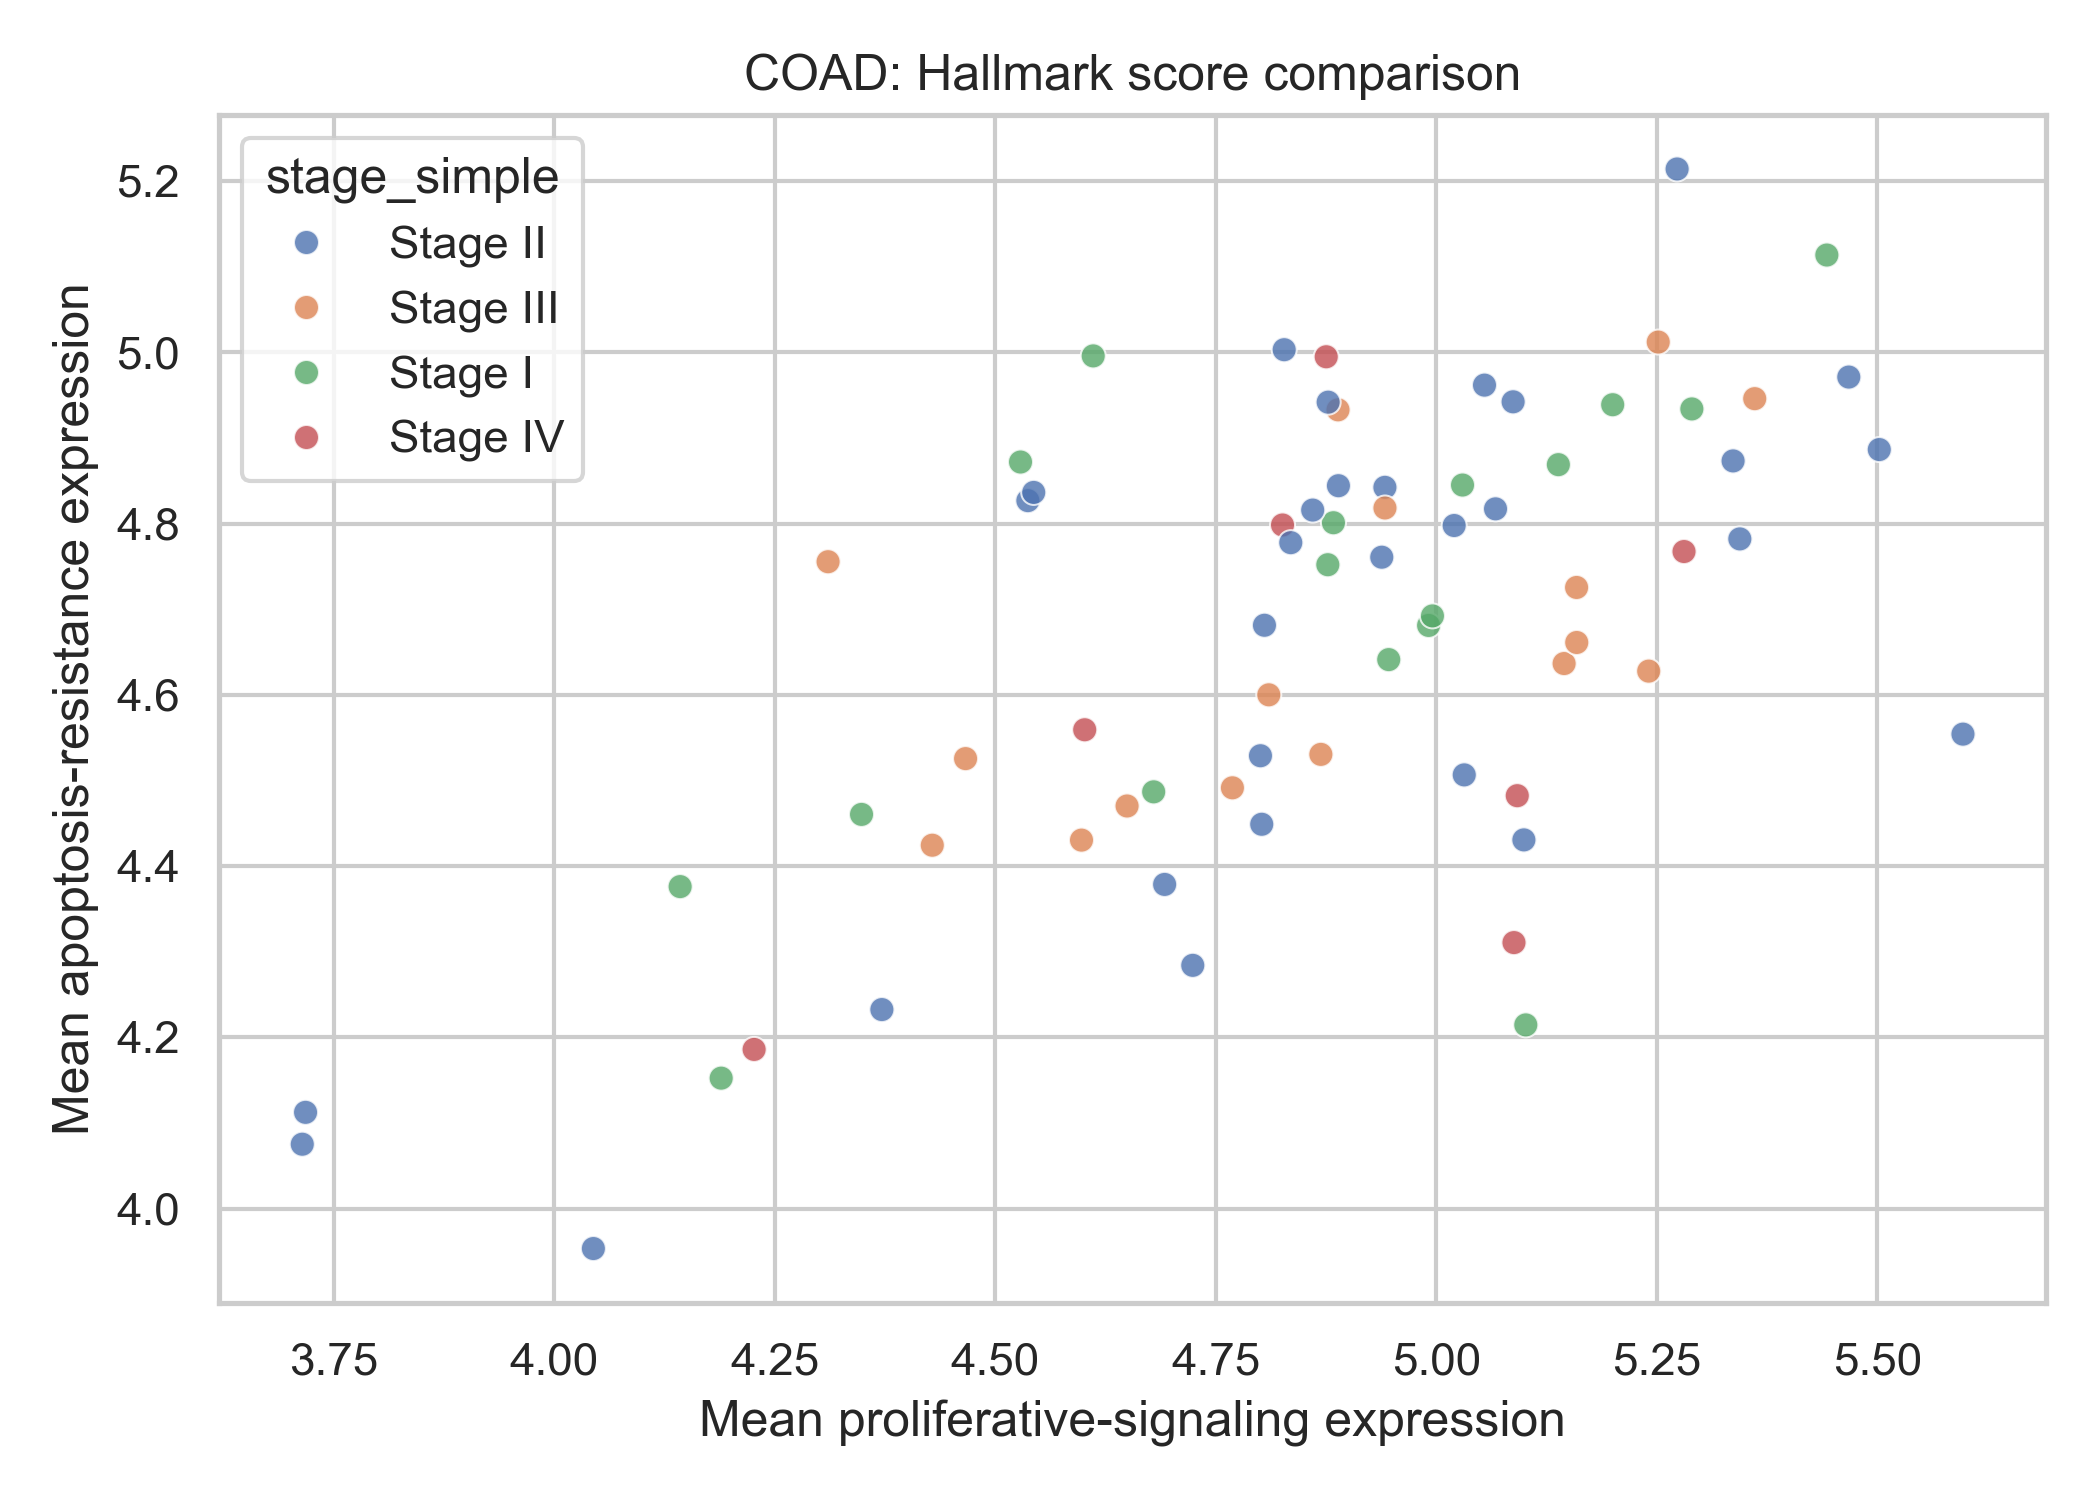

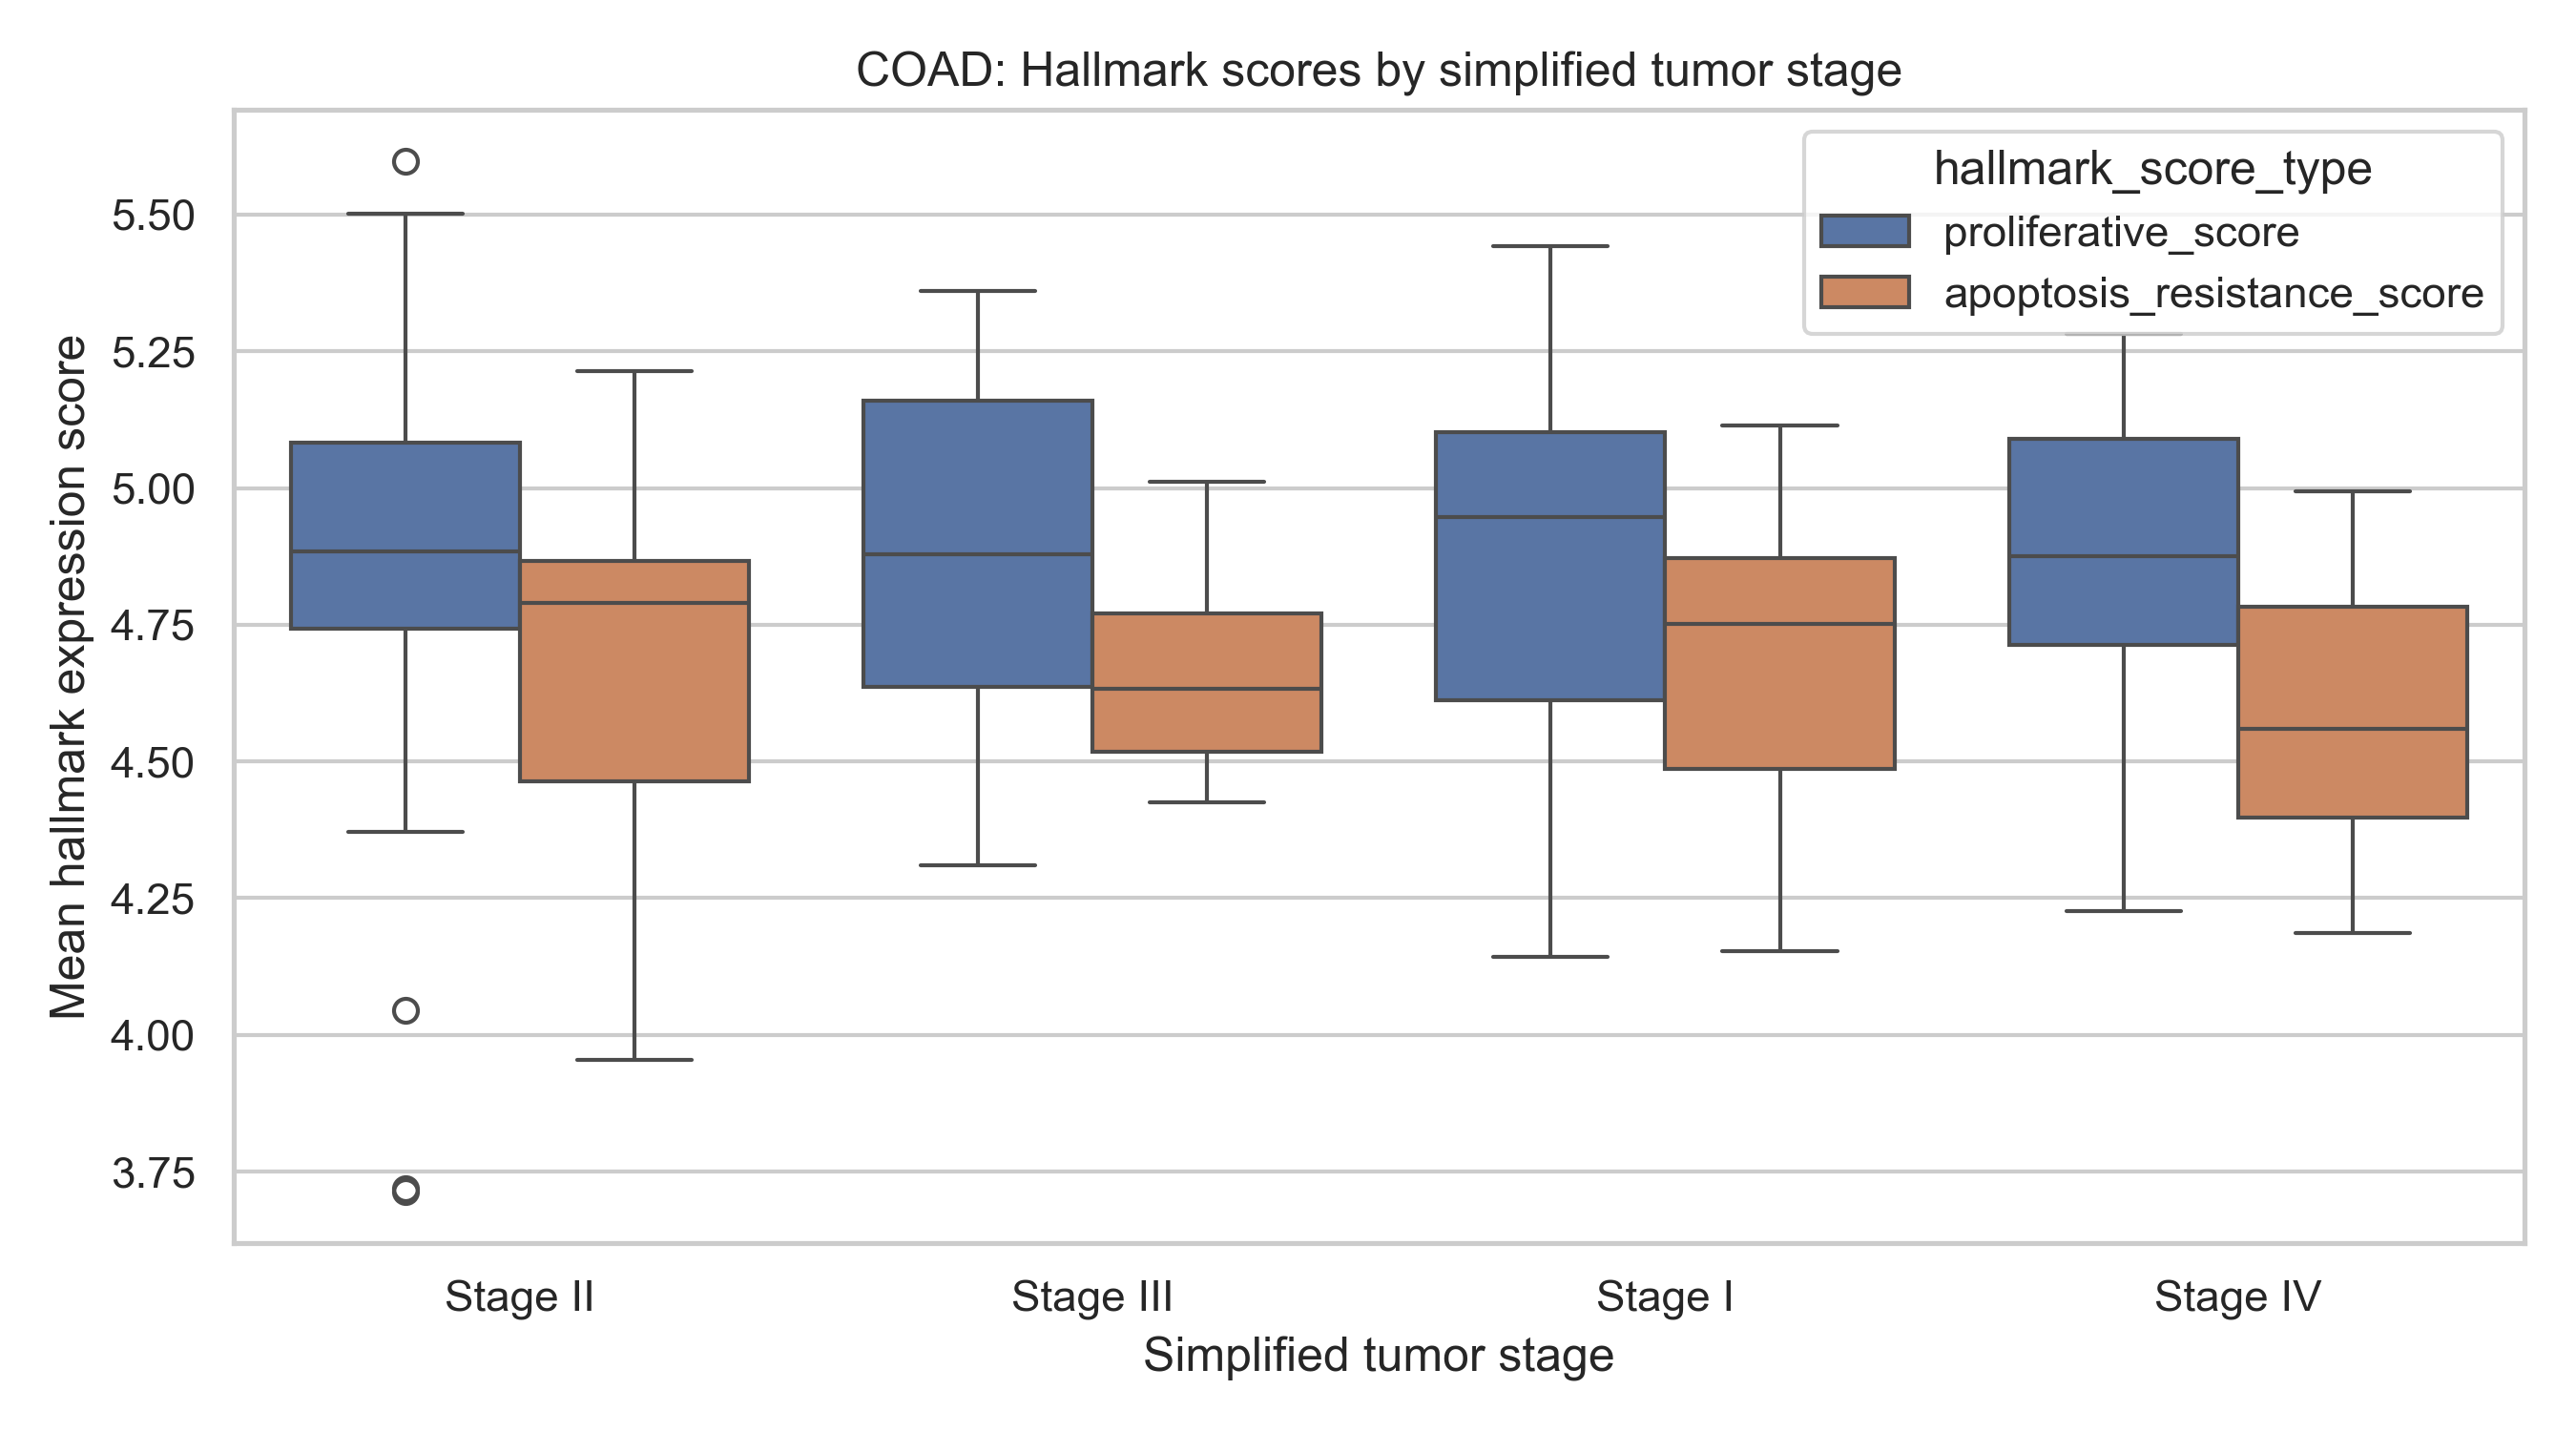

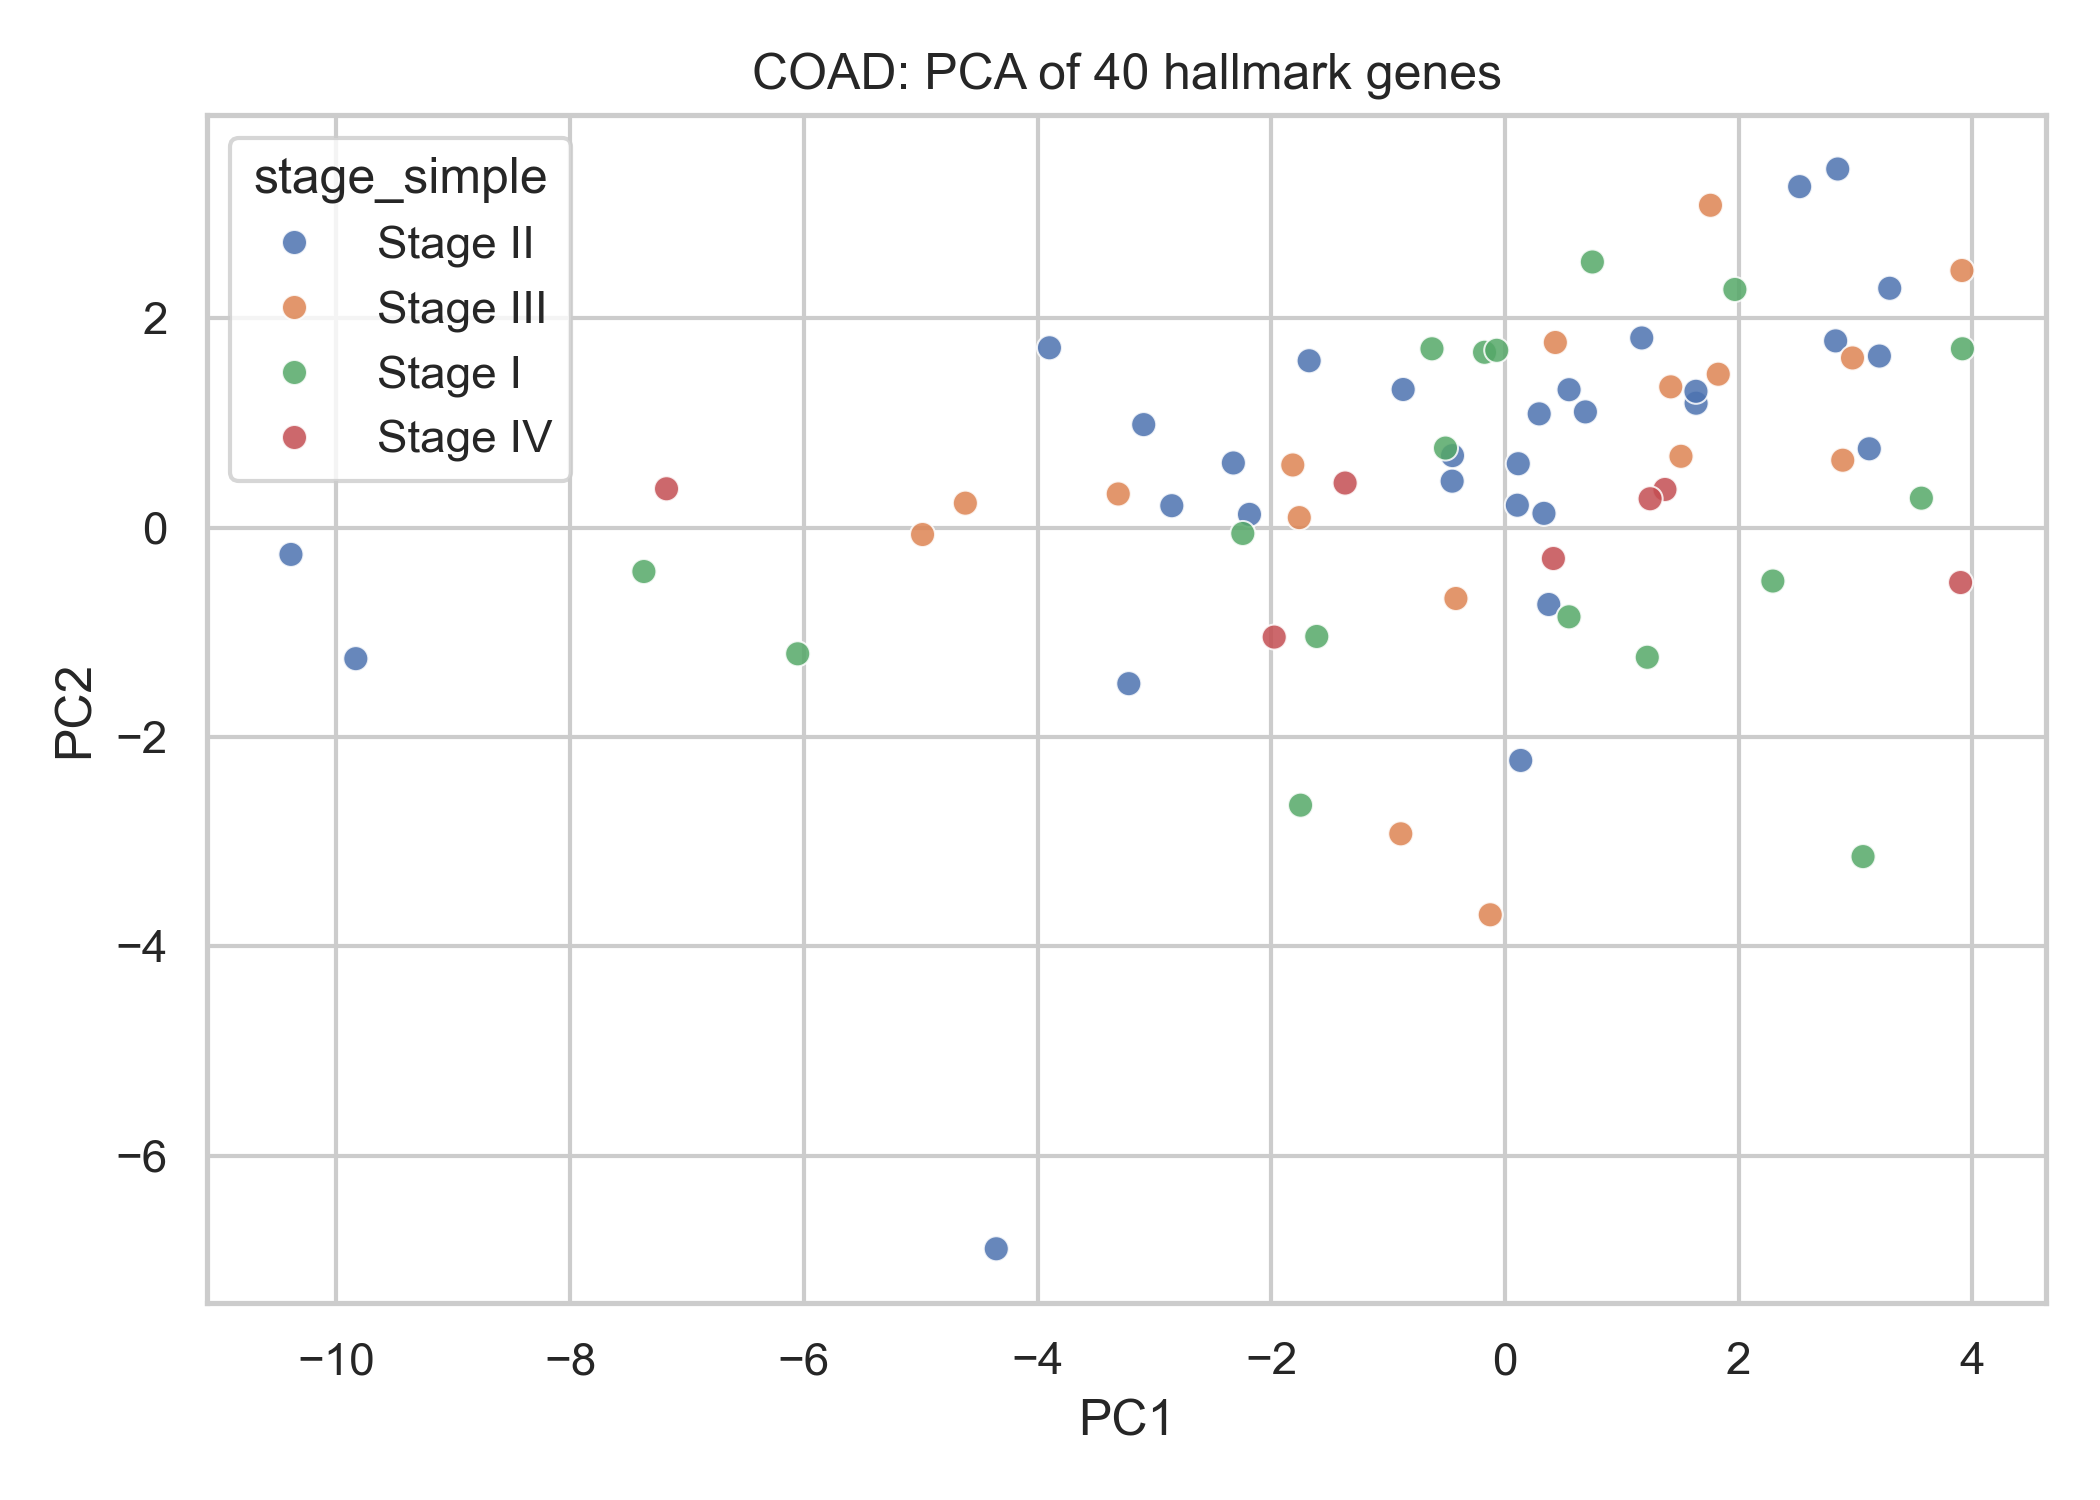

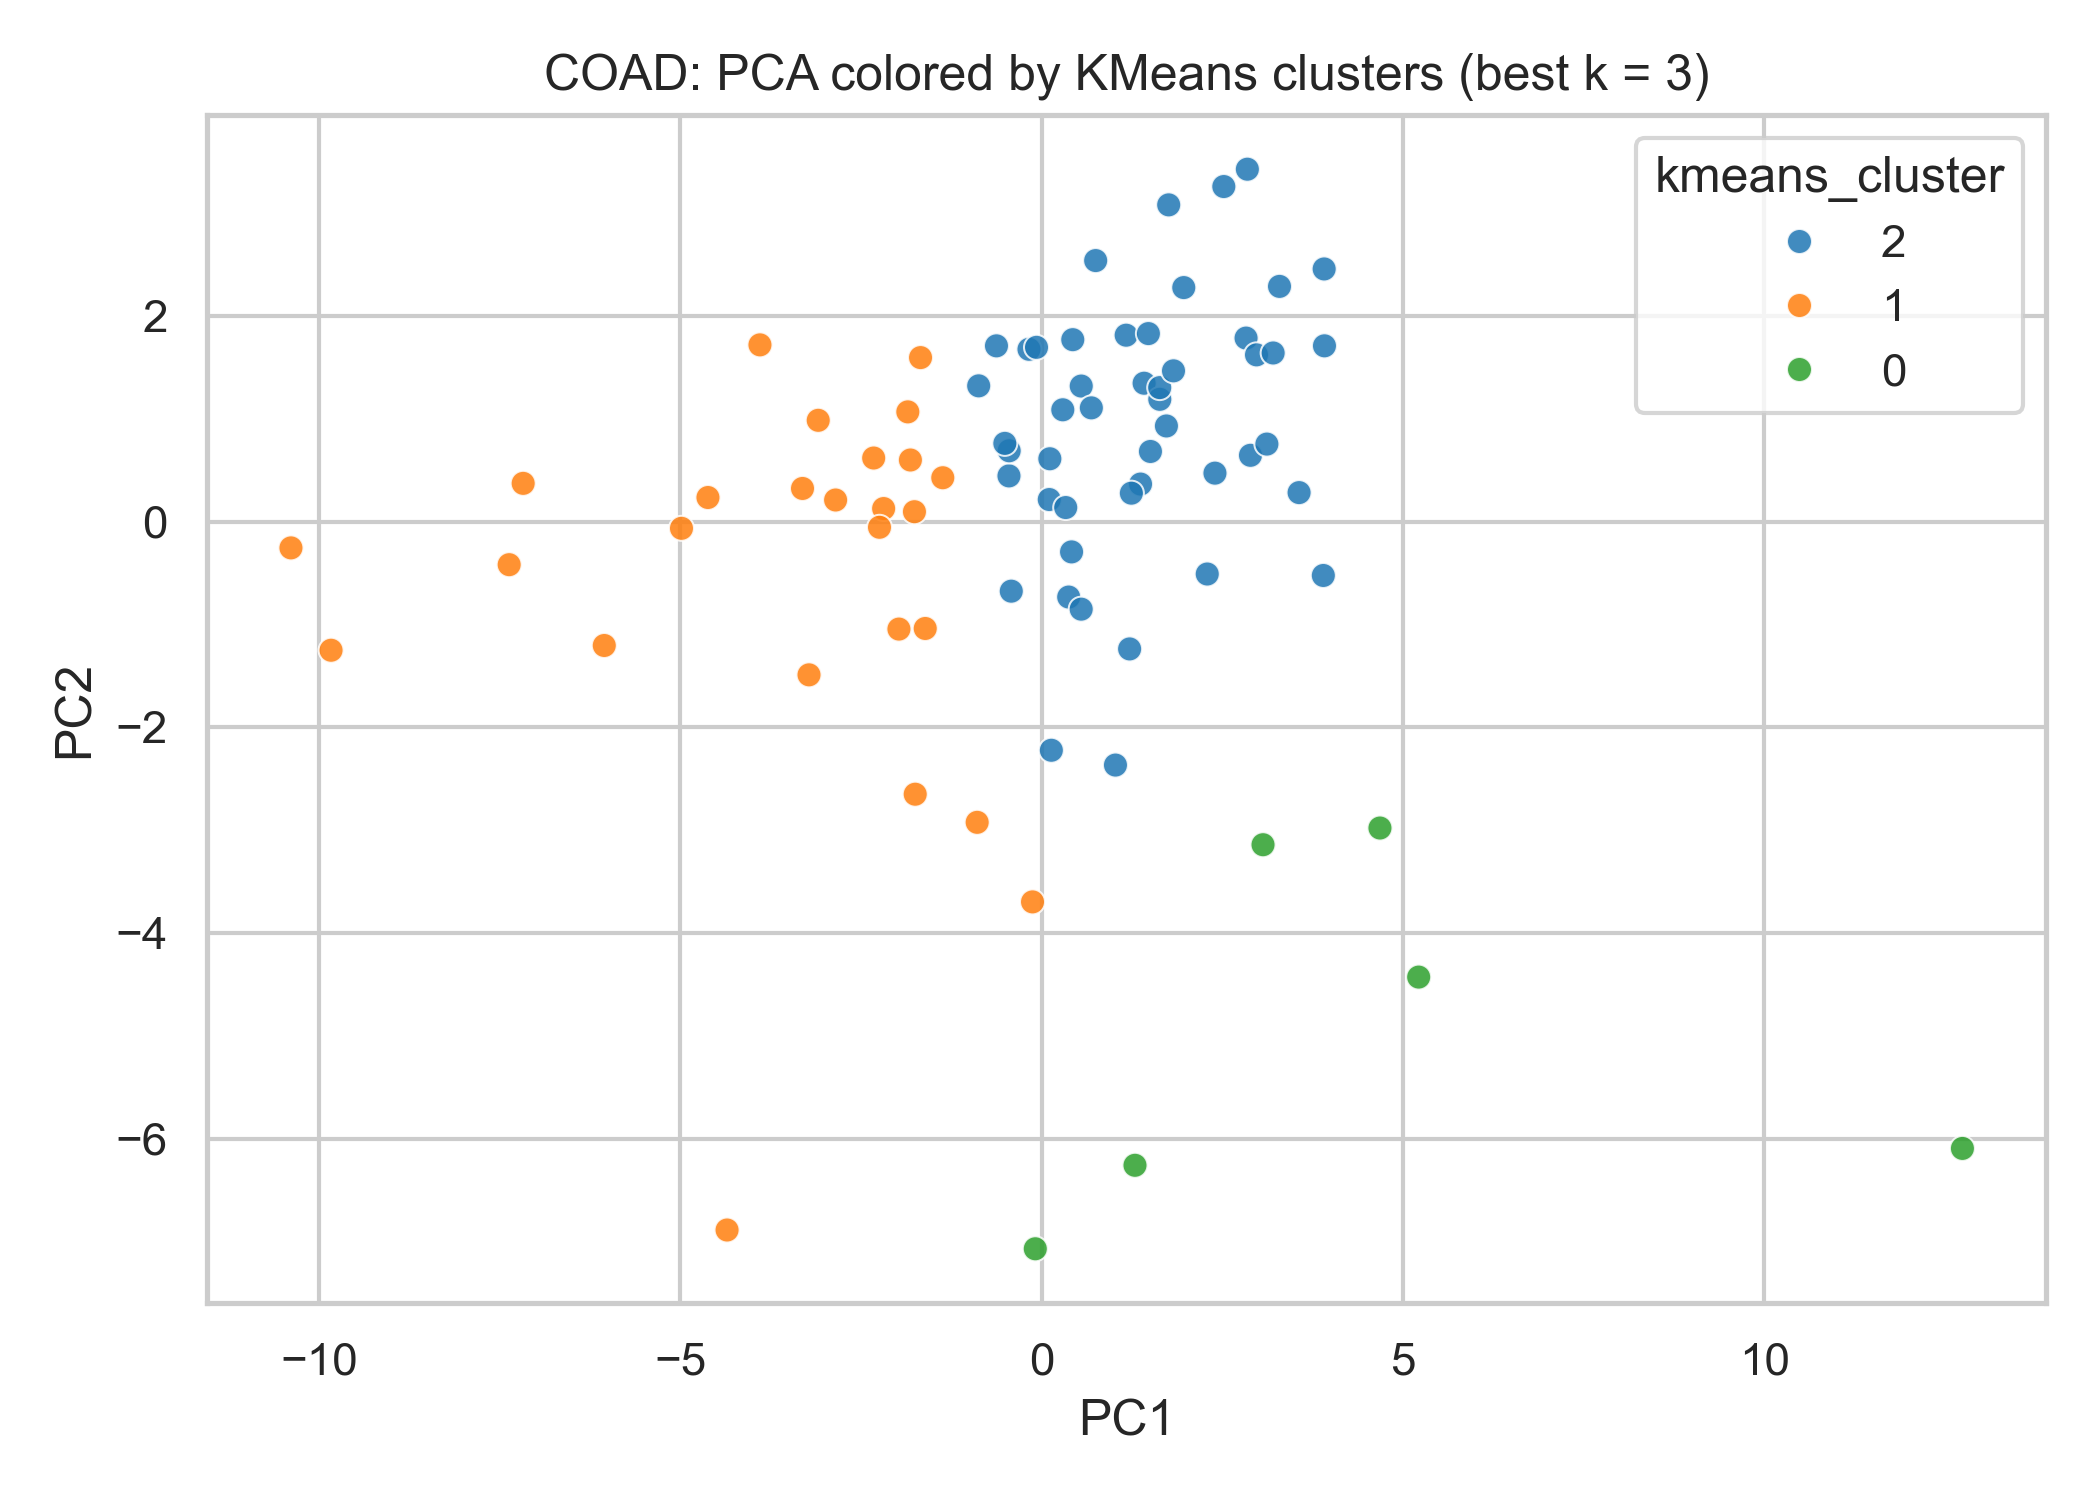

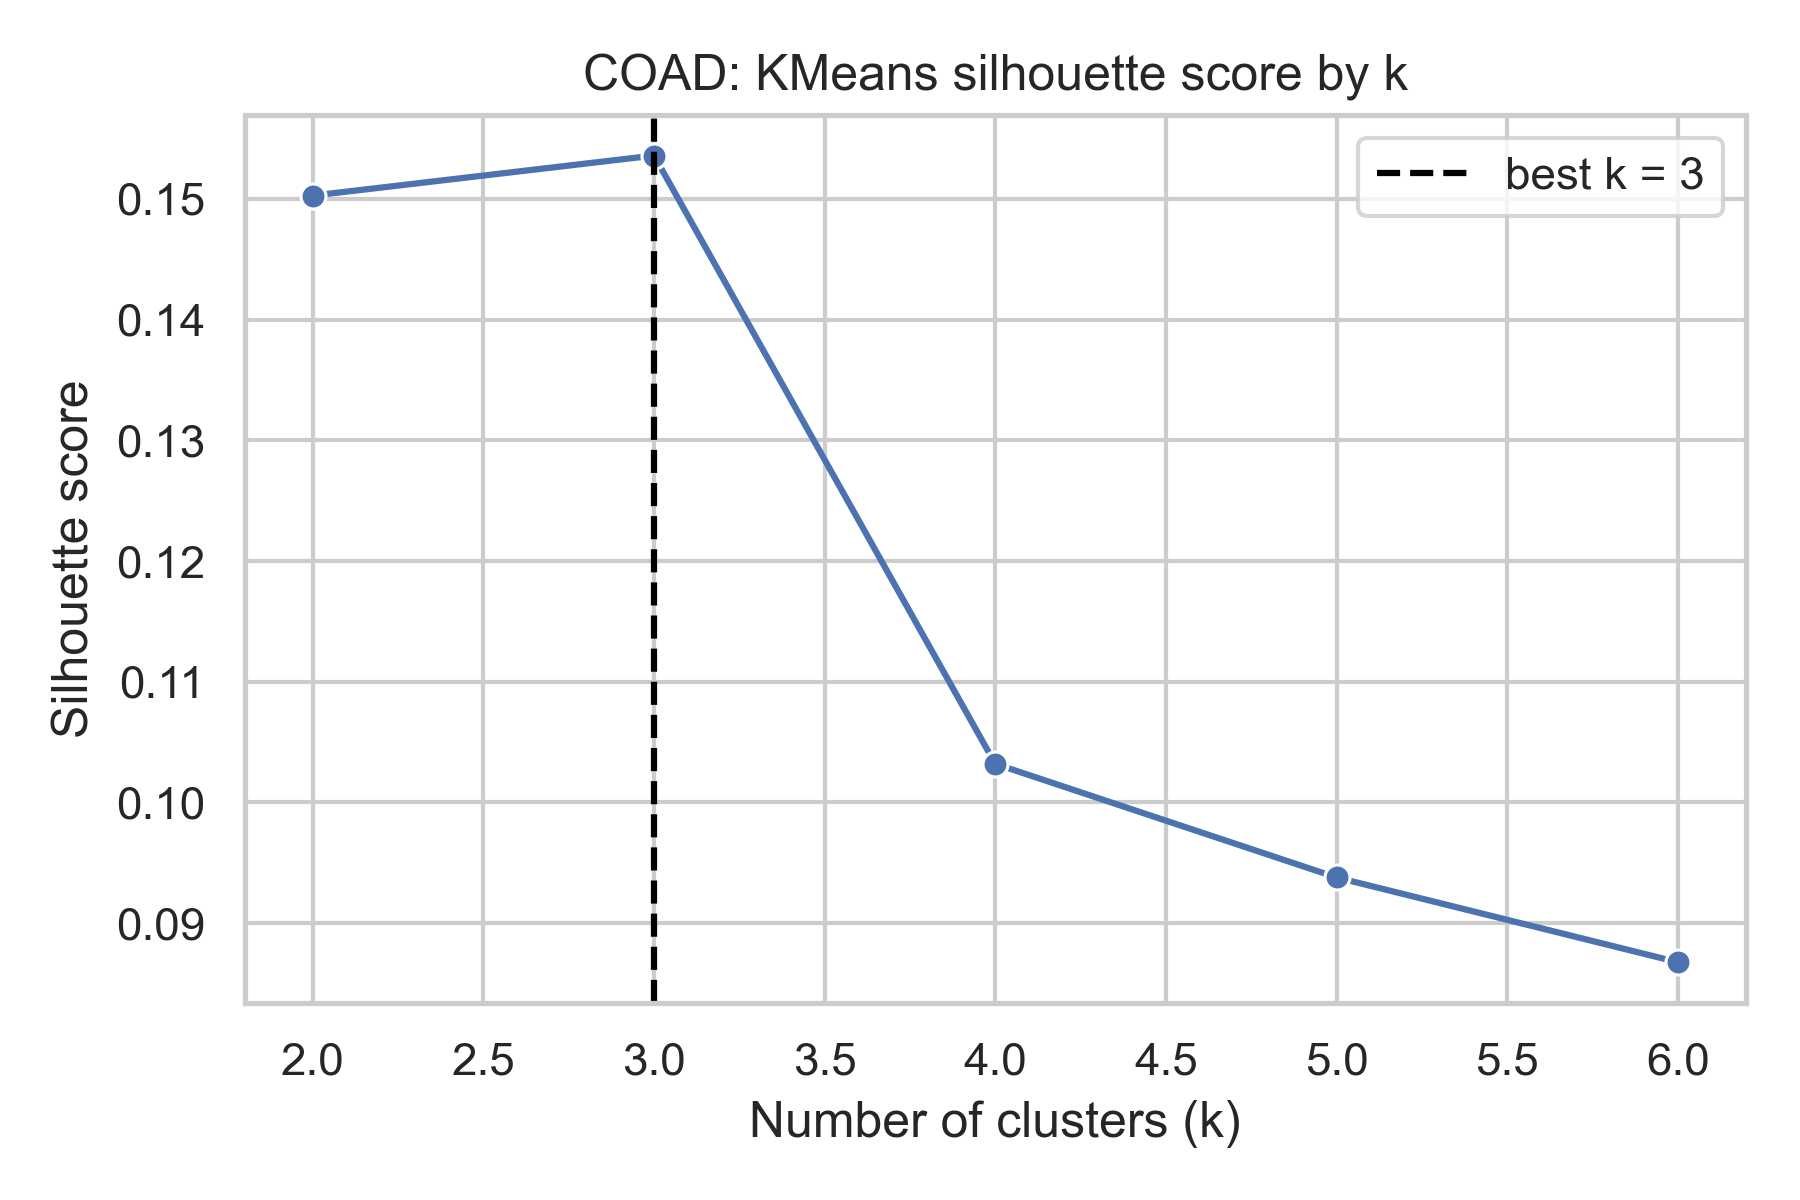

In [50]:
# Finally, we can also display the major figures we generated during our EDA workflow to visualize the relationships between hallmark scores and stage, as well as the PCA and clustering results.
from IPython.display import Image, display

results_dir = PROJECT_ROOT / "results"

display(Image(filename=str(results_dir / "COAD_hallmark_score_scatter.png")))
display(Image(filename=str(results_dir / "COAD_hallmark_scores_by_stage.png")))
display(Image(filename=str(results_dir / "COAD_PCA_by_stage.png")))
display(Image(filename=str(results_dir / "COAD_PCA_by_cluster.png")))
display(Image(filename=str(results_dir / "COAD_kmeans_silhouette.png")))

#### 10. Display the UMAP coordinates

UMAP provides a nonlinear view of local structure in the same hallmark-gene matrix. We use it here as a complementary visualization to PCA rather than as a final conclusion. Comparing PCA and UMAP helps us judge whether the apparent structure is stable across different dimensionality-reduction approaches.

,UMAP1,UMAP2,proliferative_score,apoptosis_resistance_score,cancer_type,bcr_patient_barcode,gender,race,ethnicity,age_at_diagnosis,...,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,stage_clean,stage_simple,stage_binary,kmeans_cluster
TCGA-AA-3532-01A-01R-0821-07,11.264119,-1.620861,4.805219,4.681239,COAD,TCGA-AA-3532,MALE,[Not Available],[Not Available],63.000000,...,0.000000,882.000000,NaN,NaN,0.000000,882.000000,Stage IIA,Stage II,Early,2
TCGA-AA-3842-01A-01R-1022-07,11.532536,-1.771479,4.869162,4.530510,COAD,TCGA-AA-3842,MALE,[Not Available],[Not Available],51.000000,...,0.000000,1126.000000,1.000000,396.000000,1.000000,396.000000,Stage IIIA,Stage III,Late,2
TCGA-G4-6310-01A-11R-1723-07,8.761057,-2.352844,5.144955,4.636565,COAD,TCGA-G4-6310,MALE,WHITE,NOT HISPANIC OR LATINO,69.000000,...,0.000000,1935.000000,0.000000,1935.000000,0.000000,1935.000000,Stage IIIB,Stage III,Late,2
TCGA-AA-3975-01A-01R-1022-07,12.359118,-2.960093,4.991320,4.681024,COAD,TCGA-AA-3975,MALE,[Not Available],[Not Available],80.000000,...,0.000000,1036.000000,0.000000,1036.000000,0.000000,1036.000000,Stage I,Stage I,Early,2
TCGA-AM-5820-01A-01R-1653-07,9.730977,-2.274360,5.280900,4.767320,COAD,TCGA-AM-5820,FEMALE,WHITE,NOT HISPANIC OR LATINO,59.000000,...,0.000000,14.000000,NaN,NaN,0.000000,14.000000,Stage IVA,Stage IV,Late,2
TCGA-AA-A02W-01A-01R-A00A-07,9.052812,-3.627867,5.101496,4.214700,COAD,TCGA-AA-A02W,FEMALE,[Not Available],[Not Available],73.000000,...,0.000000,1247.000000,1.000000,1005.000000,1.000000,1005.000000,Stage I,Stage I,Early,2
TCGA-CA-6719-01A-11R-1839-07,8.296686,-3.009314,5.597140,4.554142,COAD,TCGA-CA-6719,MALE,ASIAN,NOT HISPANIC OR LATINO,77.000000,...,0.000000,435.000000,NaN,NaN,1.000000,354.000000,Stage IIA,Stage II,Early,2
TCGA-G4-6295-01A-11R-1723-07,8.875164,-3.289126,4.938214,4.760688,COAD,TCGA-G4-6295,FEMALE,WHITE,NOT HISPANIC OR LATINO,70.000000,...,0.000000,254.000000,NaN,NaN,0.000000,254.000000,Stage II,Stage II,Early,2
TCGA-AA-3949-01A-01R-1022-07,10.654593,-1.415373,4.310490,4.755428,COAD,TCGA-AA-3949,FEMALE,[Not Available],[Not Available],87.000000,...,0.000000,791.000000,0.000000,791.000000,0.000000,791.000000,Stage IIIB,Stage III,Late,1
TCGA-AA-3815-01A-01R-1022-07,11.048312,-2.047903,4.827595,5.002941,COAD,TCGA-AA-3815,FEMALE,[Not Available],[Not Available],65.000000,...,0.000000,1005.000000,0.000000,1005.000000,0.000000,1005.000000,Stage IIA,Stage II,Early,2


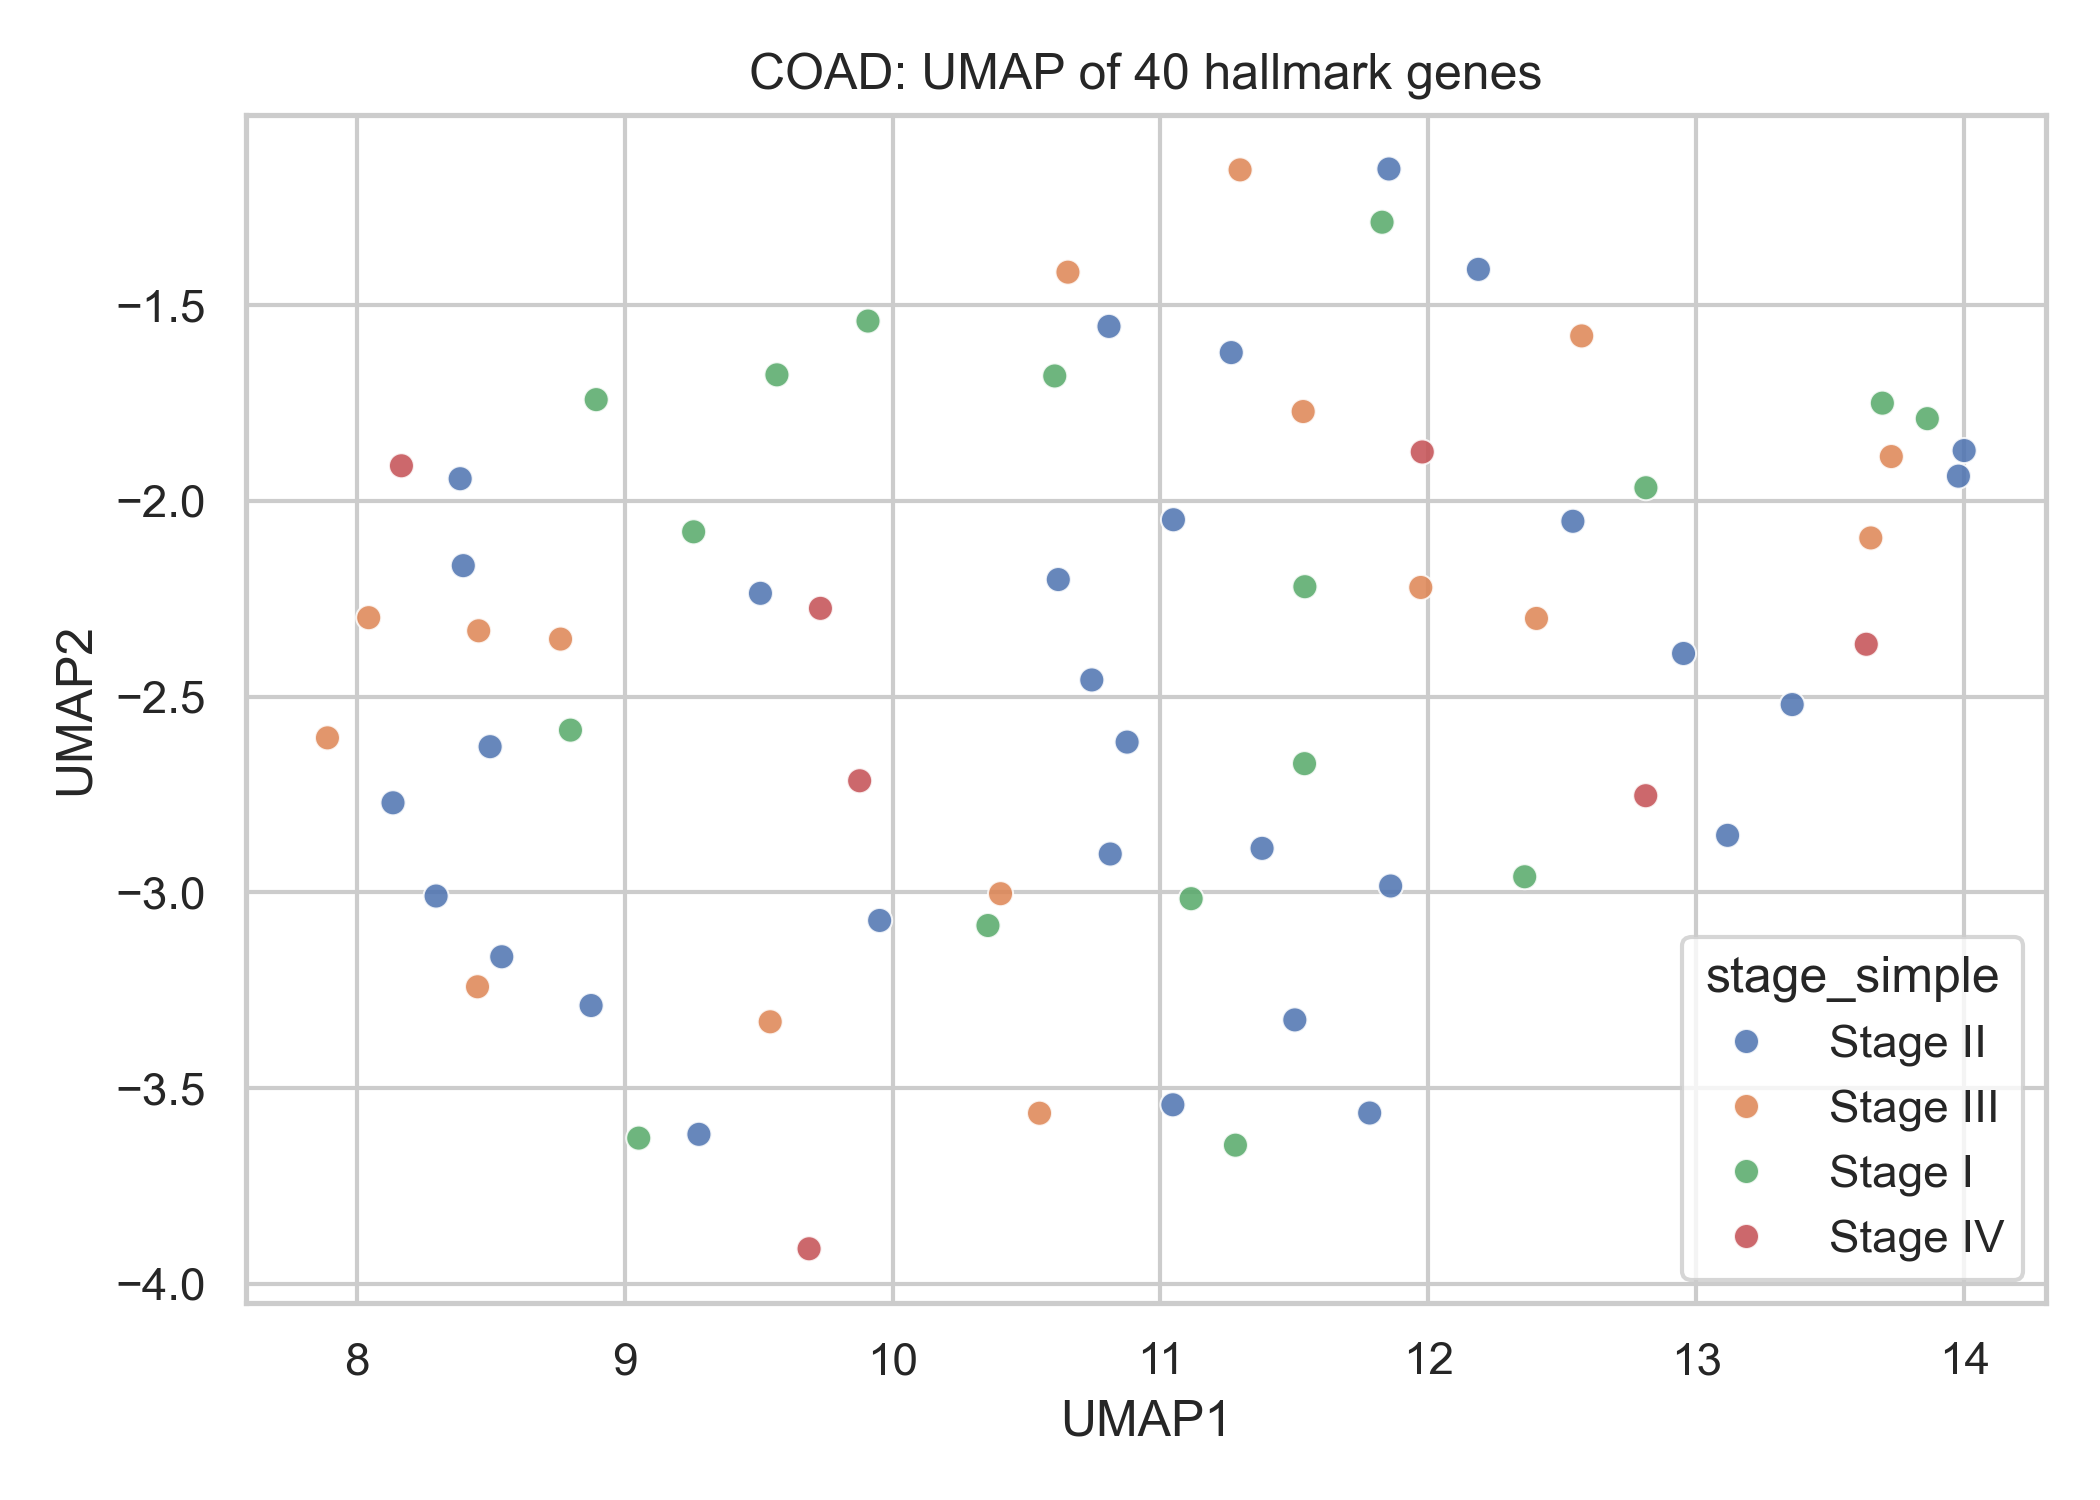

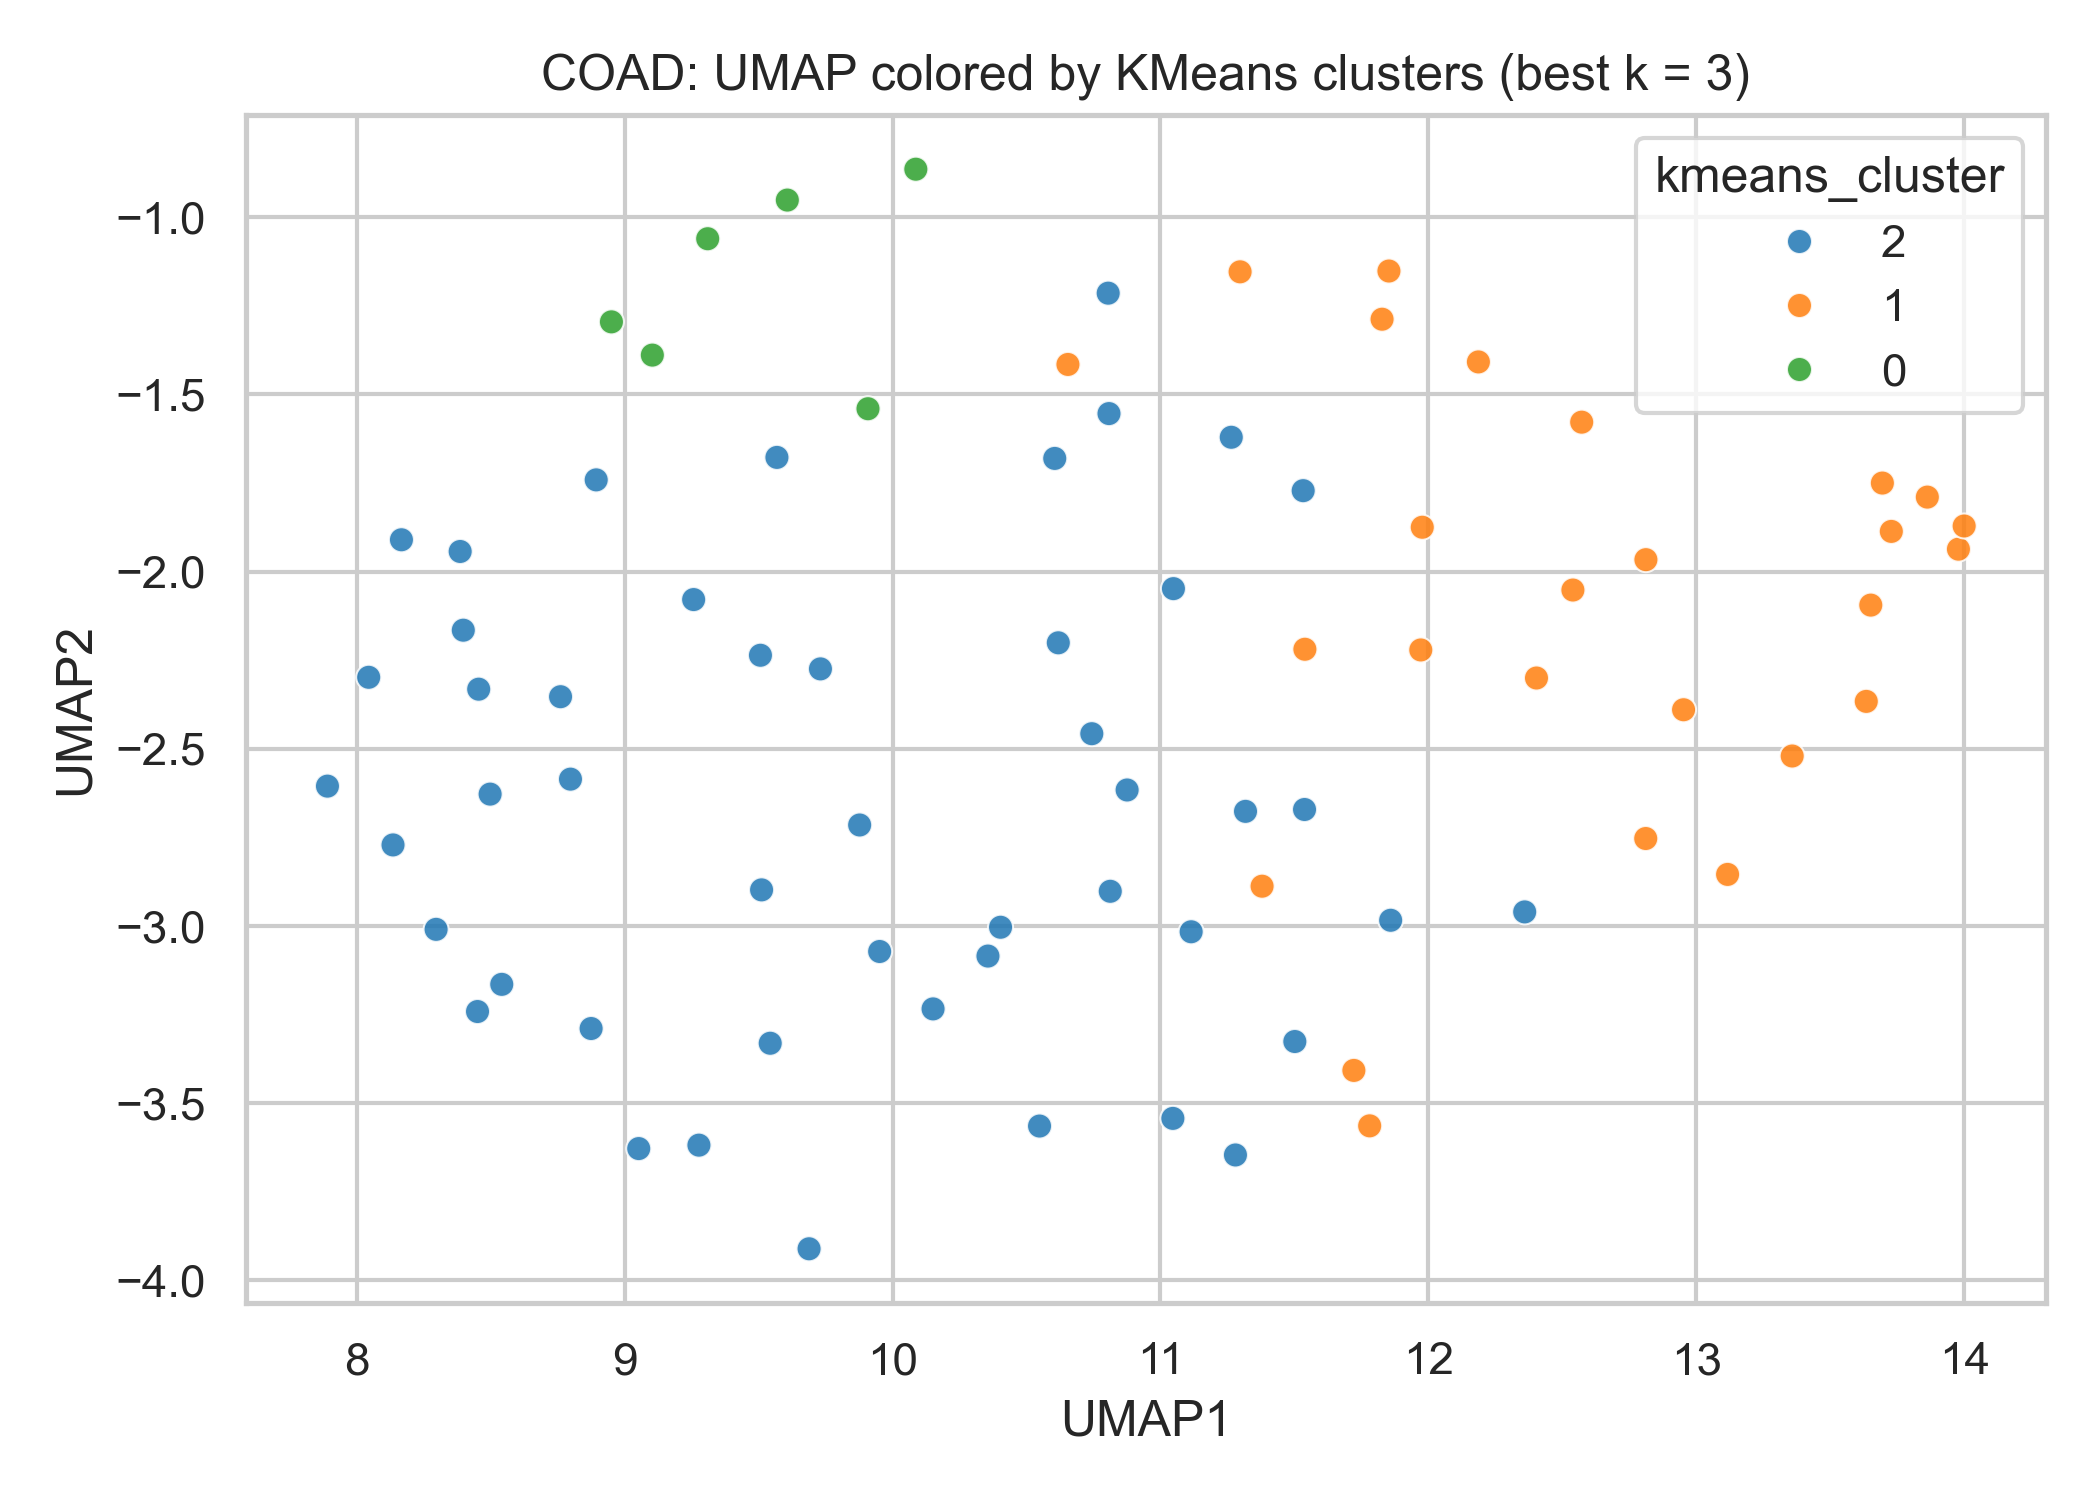

In [51]:
# If UMAP was available and dovnloaded in our current environment, we can also display the UMAP results and figures. 
if eda_outputs["umap_df"] is not None:
    display(eda_outputs["umap_df"].head(10))
    display(Image(filename=str(results_dir / "COAD_UMAP_by_stage.png")))
    display(Image(filename=str(results_dir / "COAD_UMAP_by_cluster.png")))
else:
    print("No UMAP available.")

#### Overall Unsupervised Patterns Interpretation

Our unsupervised results suggest that the two hallmark programs are related but do not clearly separate tumor stage. In our hallmark-score scatterplot, samples with **higher proliferative scores** generally also tended to have **higher apoptosis-resistance scores**, indicating partial coordination between the two hallmarks. However, the stage-based boxplots clearly show substantial overlap across Stage I–IV, suggesting that these summary scores alone **do not cleanly distinguish stage**. On a similar note, PCA and UMAP did not reveal strong stage-separated groupings, and the best K-means solution had a low silhouette score of 0.154 for k = 3, indicating there was a weak cluster structure in our 40-gene feature space.

#### 11. Run the supervised training/validation workflow

In this step, we transition from exploratory analysis to supervised learning. Our goal is now to predict whether a COAD tumor belongs to the **Early** or **Late** stage group using hallmark-expression features. Importantly, this workflow uses only the **training** and **validation** datasets and does not use the **test** dataset.

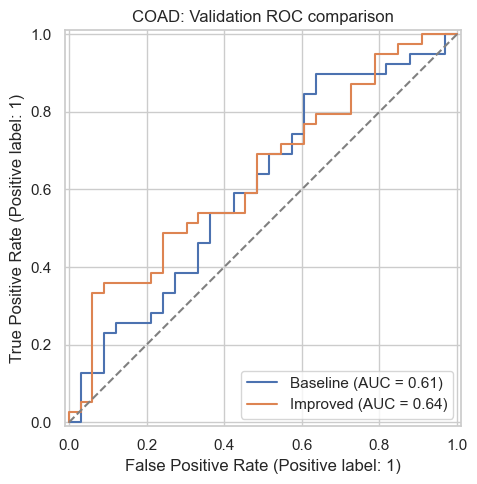

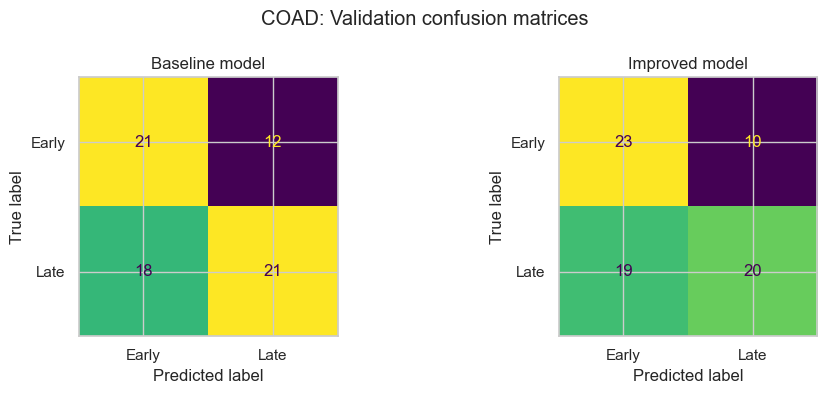

,model,split,n_samples,accuracy,balanced_accuracy,precision,recall,f1,auroc
0,baseline_logreg_40genes,train,70,0.900000,0.858927,0.944444,0.739130,0.829268,0.974098
1,baseline_logreg_40genes,validation,72,0.583333,0.587413,0.636364,0.538462,0.583333,0.607615
2,improved_logreg_40genes_plus_scores_age_balanced,train,70,0.857143,0.860315,0.740741,0.869565,0.800000,0.916744
3,improved_logreg_40genes_plus_scores_age_balanced,validation,72,0.597222,0.604895,0.666667,0.512821,0.579710,0.637141


In [52]:
# After completing the EDA, we now move to supervised learning.
# This uses only the training and validation splits and does not touch the test set.
supervised_results = main.run_supervised_modeling()
display(supervised_results["comparison_df"])

#### 12. Compare baseline and improved model metrics

This table compares the baseline and improved logistic-regression models on both the training and validation datasets. Reporting both in-sample and out-of-sample metrics helps us determine whether the model is learning a useful biological pattern that generalizes, rather than simply memorizing the training data.

In [ ]:
# We can also display the ROC curve comparison data for the validation set 
# compares the baseline and improved models.
display(supervised_results["comparison_df"])

,model,split,n_samples,accuracy,balanced_accuracy,precision,recall,f1,auroc
0,baseline_logreg_40genes,train,70,0.900000,0.858927,0.944444,0.739130,0.829268,0.974098
1,baseline_logreg_40genes,validation,72,0.583333,0.587413,0.636364,0.538462,0.583333,0.607615
2,improved_logreg_40genes_plus_scores_age_balanced,train,70,0.857143,0.860315,0.740741,0.869565,0.800000,0.916744
3,improved_logreg_40genes_plus_scores_age_balanced,validation,72,0.597222,0.604895,0.666667,0.512821,0.579710,0.637141


#### 13. Display the validation ROC comparison

The ROC curves summarize how well each model separates Early-stage from Late-stage tumors across all possible decision thresholds. Because logistic regression outputs probability scores, AUROC is a useful threshold-independent metric for comparing the baseline and improved models.

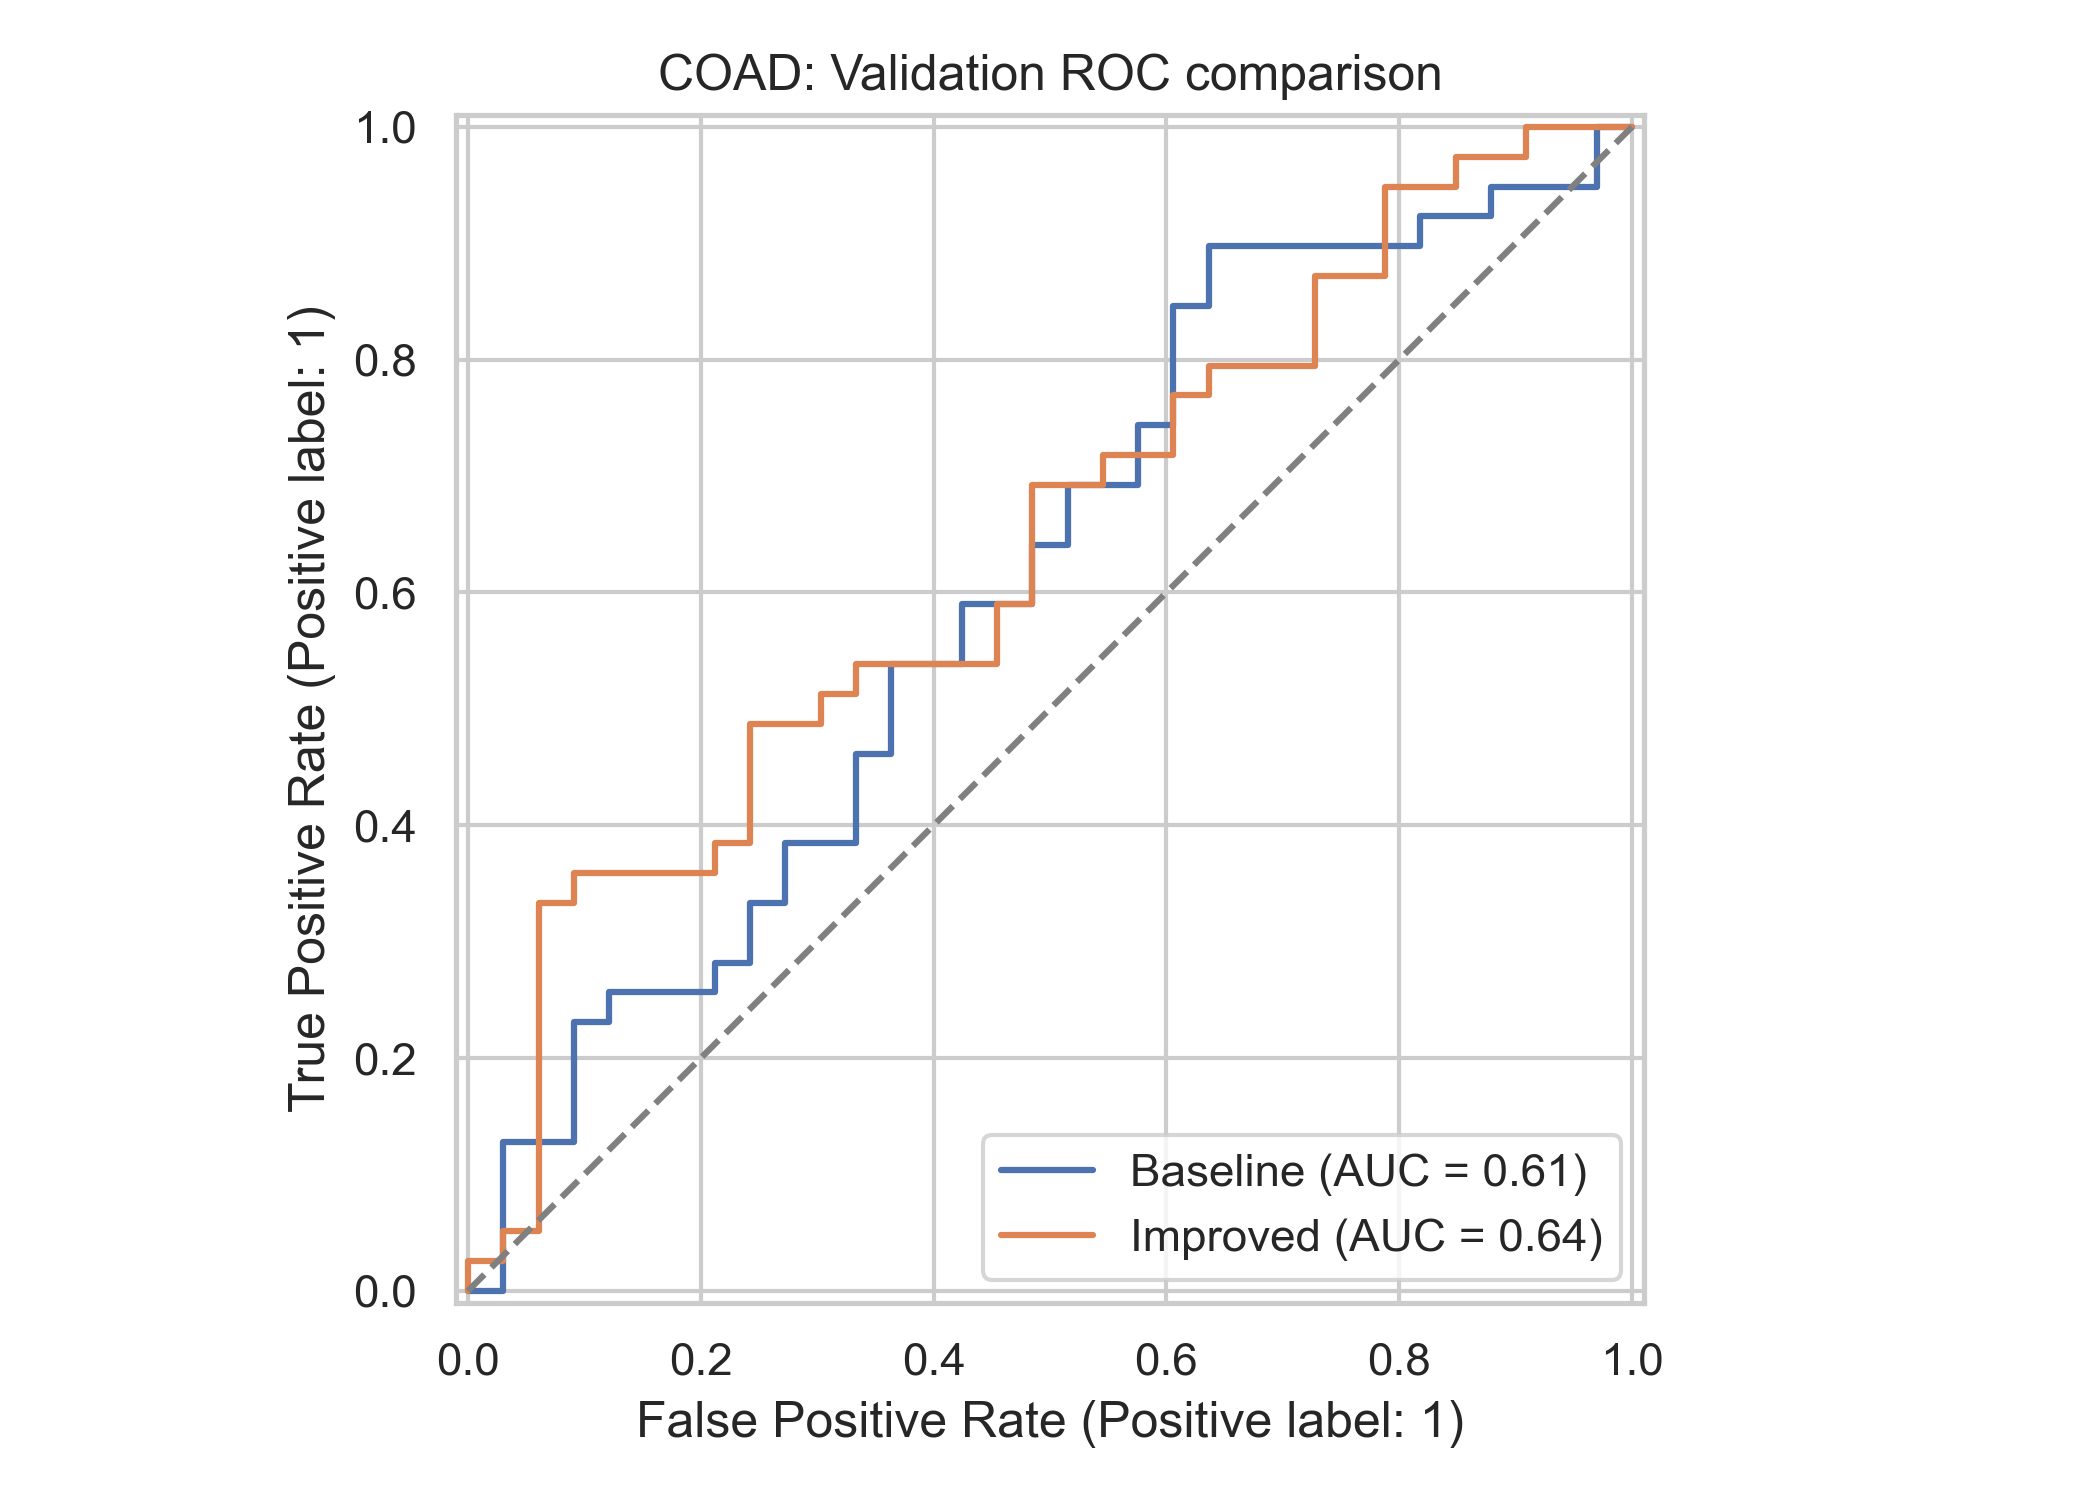

In [ ]:
# Finally, we can also display the ROC curve comparison figure for the validation set
display(Image(filename=str(results_dir / "COAD_validation_ROC_comparison.png")))

#### 14. Display the validation confusion matrices

The confusion matrices show model behavior at the default decision threshold of 0.5. They make it easier to see the balance between correctly identifying Late-stage tumors and incorrectly labeling Early-stage tumors as Late, which is important for interpreting model error in a clinically meaningful way.

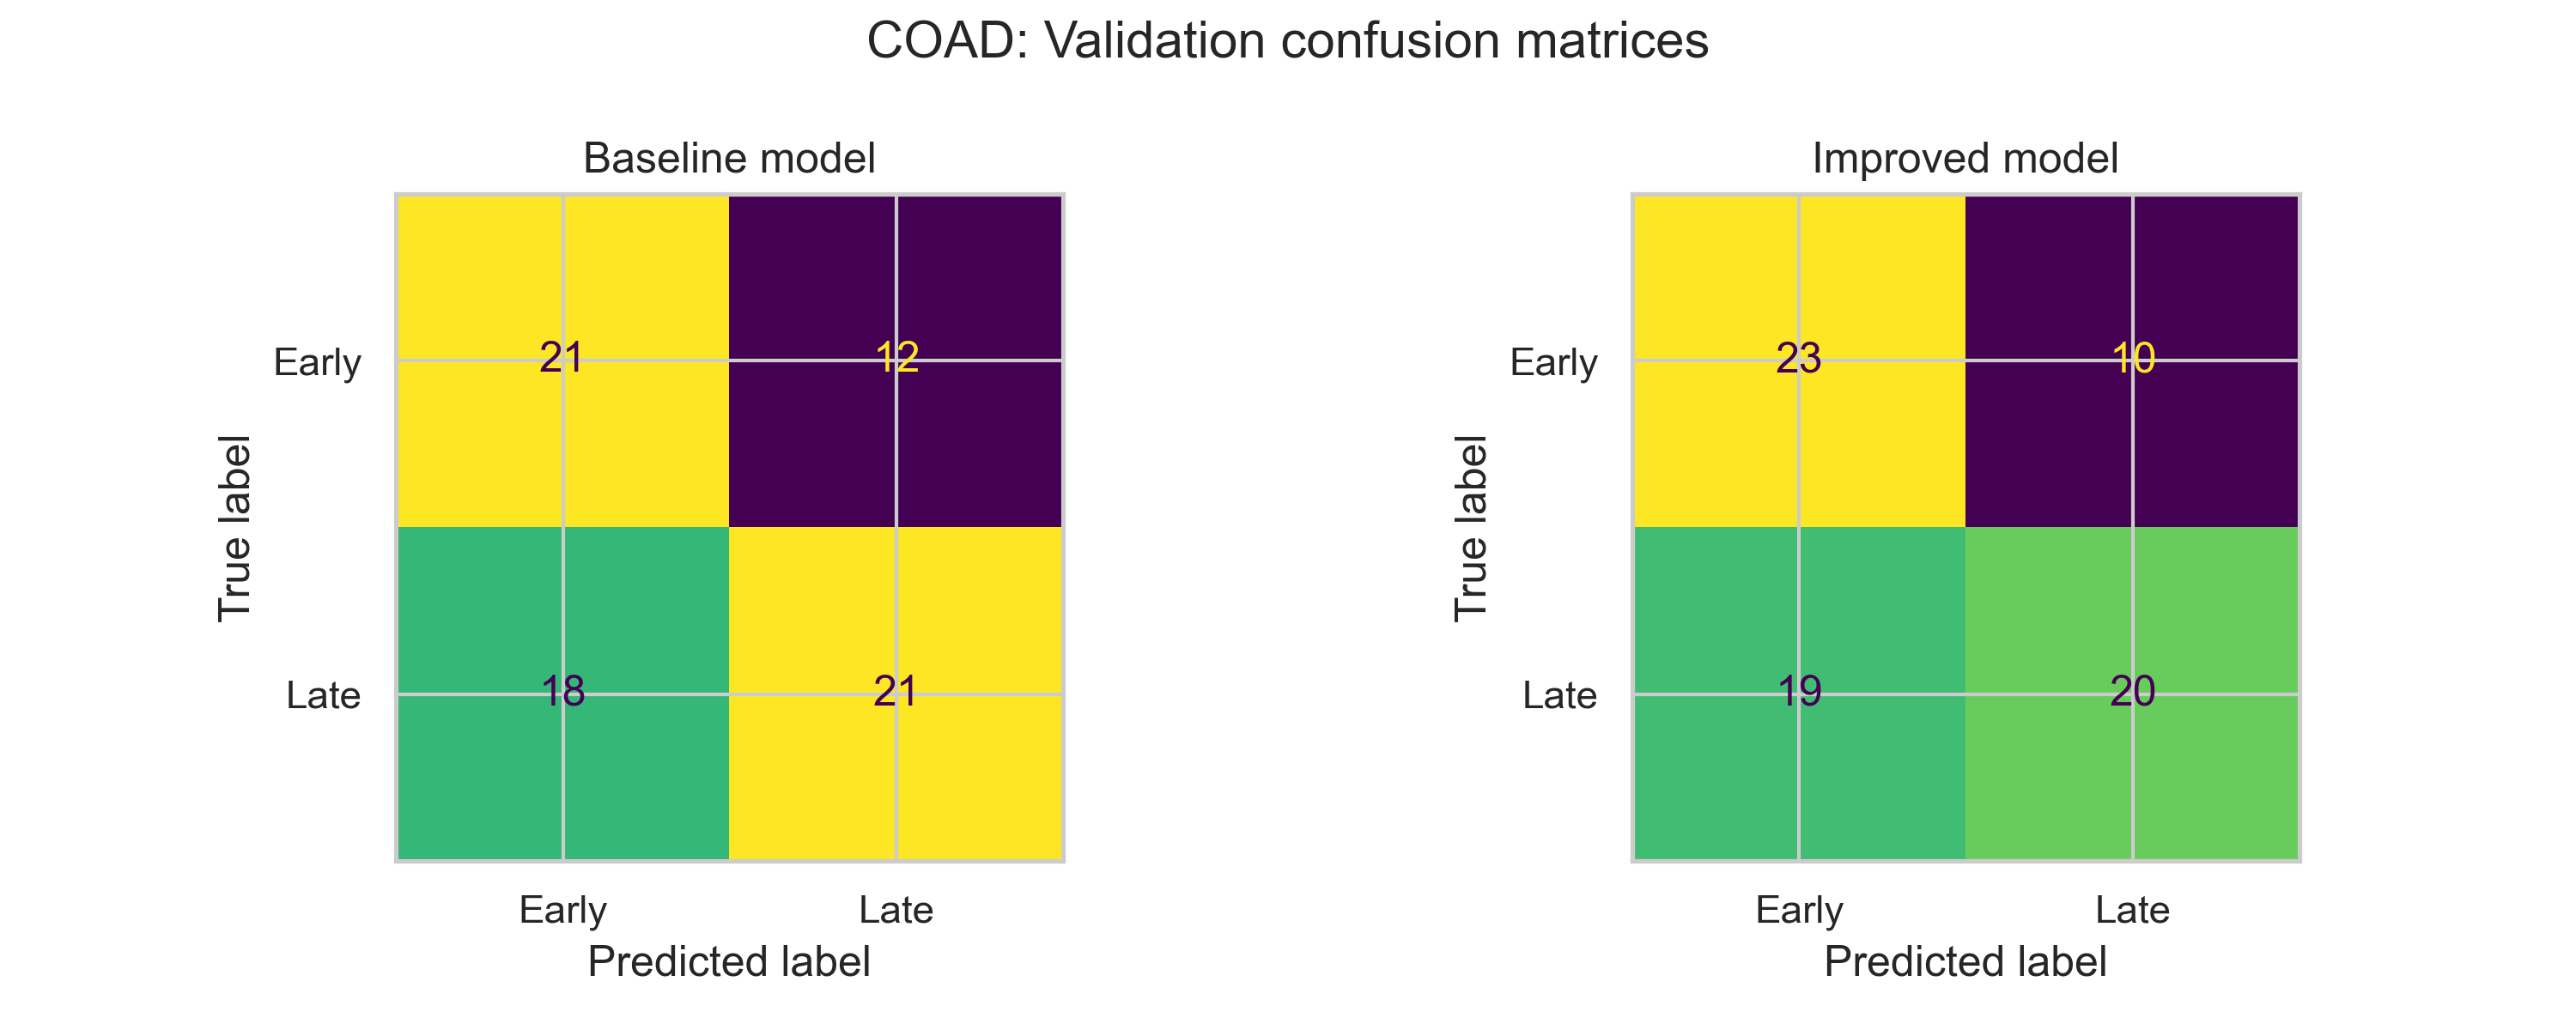

In [ ]:
# We can also display the confusion matrix comparison figure for the validation set
display(Image(filename=str(results_dir / "COAD_validation_confusion_matrices.png")))

#### 15. Top coefficients from the improved model

These coefficients provide a first-pass look at which features most strongly influence the improved logistic-regression model. Because logistic regression is interpretable, the coefficient table helps connect predictive performance back to the biological story of proliferative signaling, apoptosis resistance, and tumor progression.

In [ ]:
#  display the coefficient table for the improved model which shows the top features contributing to the model predictions.
display(supervised_results["improved"]["coef_df"].head(15))

,feature,coefficient,abs_coefficient
0,EGFR,0.336864,0.336864
12,FGFR1,0.287371,0.287371
30,CASP9,-0.278940,0.278940
35,BCL2L11,0.272989,0.272989
7,MYC,-0.261921,0.261921
1,ERBB2,-0.257498,0.257498
9,JUN,-0.223860,0.223860
26,BAX,-0.205219,0.205219
31,FAS,-0.197033,0.197033
10,MET,-0.194539,0.194539


#### Supervised Results Interpretation

Our supervised results show that our **improved** logistic-regression model generalized slightly better than our **baseline** model, but performance remained modest overall. On the validation set, the **improved** model achieved **higher AUROC**, balanced accuracy, and accuracy than the **baseline**, which suggests to us that adding hallmark-summary scores, age, class balancing, and stronger regularization was directionally helpful. However, the gap between training and validation performance remained substantial for both of our models, which indicates that the selected hallmark-expression features alone do not provide strong stage-prediction power in our dataset.

## Verify and validate your analysis: 

We evaluated model performance using both **threshold-independent** and **threshold-dependent** metrics on the validation dataset. **AUROC** was our primary threshold-independent metric because logistic regression outputs probabilities, and AUROC summarizes how well our model ranks Late-stage tumors above Early-stage tumors across all thresholds. At the default threshold of **0.5**, we also examined the **confusion matrix**, **accuracy**, **balanced accuracy**, **precision, recall**, and **F1 score**8.

The baseline **logistic-regression model** performed very well on the 'training set' (**AUROC = 0.974**, **accuracy = 0.900**) but much worse on the 'validation set' (**AUROC = 0.608**, **accuracy = 0.583**), suggesting overfitting. The improved model reduced training performance somewhat (**AUROC = 0.917**, **accuracy = 0.857**) but slightly improved validation performance (**AUROC = 0.637**, **accuracy = 0.597**, **balanced accuracy = 0.605**). This suggests that adding hallmark-summary scores, age at diagnosis, class balancing, and stronger regularization modestly improved our generalization, which aligns and make sense in the end.

The confusion matrices also show a tradeoff in **error type**. Compared with the baseline model, the improved model slightly **reduced false positives** for **Late-stage classification** but did not eliminate substantial misclassification overall. Therefore, the improved model is better interpreted as a modest improvement rather than a strong predictive classifier for our sets of data.

## Conclusions and Ethical Implications: 

**Conclusions**

Our final analysis suggests that our two selected hallmark programs are biologically relevant in COAD, but they do not strongly track tumor stage on their own. In the unsupervised analysis, proliferative-signaling scores and apoptosis-resistance scores showed some positive association across samples, but our stage-based boxplots overlapped substantially. PCA and UMAP also did not show strong separation of Stage I–IV tumors, and the best K-means solution had a low silhouette score of **0.154**. This indicated to us that there was a weak cluster structure in our 40-gene feature space.

In the supervised analysis, the improved logistic-regression model performed slightly better than the baseline on the validation set, with AUROC increasing from **0.608** to **0.637** and balanced accuracy increasing from **0.587** to **0.605**. However, overall validation performance remained modest, and training performance was much stronger than validation performance, which suggest our limited generalization and some overfitting was present. Overall, these results only partially support our original hypothesis: *the two hallmark programs appear coordinated in some tumors, but they are not sufficient by themselves to strongly predict simplified tumor stage in this dataset*.

From a modeling perspective, our results highlight a key lesson: biological relevance does not guarantee predictive power. While the selected hallmark genes are mechanistically meaningful, they capture only a subset of the complexity driving tumor progression. Tumor stage reflects not only intrinsic tumor biology but also interactions with the tumor microenvironment, immune system, and broader systemic factors that are not captured in a 40-gene panel.

**Ethical Implications**

In an ethical sense, these findings carry important ethical considerations for the use of machine learning in biomedical contexts. First, they emphasize that models built on limited datasets should not be used for clinical decision-making without extensive external validation. Misclassification of tumor stage (particularly underestimating late-stage disease) could lead to inappropriate treatment decisions and harm to patients.

Second, our dataset represents a subsampled and potentially non-representative cohort, meaning that learned patterns may not generalize across diverse patient populations. If such models were deployed without addressing these biases, they could contribute to health disparities, especially for underrepresented groups in genomic datasets.

Finally, our work highlights the importance of interpretability and transparency. While more complex models could potentially improve predictive performance, simpler models like logistic regression allow us to understand which biological features are contributing to predictions. In a clinical setting, this interpretability is critical for building trust and ensuring that models are used responsibly.

Overall, our study supports the idea that hallmark-based gene expression analysis is valuable for understanding tumor biology, but insufficient on its own for clinical prediction.

## Limitations and Future Work: 
**Limitations**

Several limitations in our study likely contributed to the modest predictive performance and should be considered when interpreting our results:


1) Our analysis focused on a 40-gene hallmark panel, which, while biologically interpretable, captures only a small fraction of the molecular complexity of COAD. Important pathways such as immune response, angiogenesis, metabolism, and genome instability were not included.
2) The training dataset contains a relatively small number of COAD samples which limits statistical power and increases the risk of overfitting. Additionally, variability in metadata completeness and tumor annotation introduces noise into the analysis.
3) We reduced tumor stage into a binary classification (Early vs. Late), which may oversimplify meaningful biological differences between stages. This likely reduces the model’s ability to detect more nuanced relationships.
4) Our evaluation does not fully test generalizability to independent datasets or clinical populations.
5) Our model relies solely on RNA-expression data, ignoring other important data types such as DNA mutations, copy-number variation, epigenetics, and proteomics, all of which contribute to tumor behavior.

**Future Work**

To build on our findings, several improvements could strengthen both the biological insight and predictive performance of this analysis:

1) Incorporating additional cancer hallmarks (e.g., angiogenesis, immune evasion, genome instability) could provide a more complete representation of tumor biology and improve model performance.
2) Instead of relying on individual gene expression, applying methods such as Gene Set Variation Analysis or enrichment-based scoring could better capture coordinated pathway activity.
3) Combining RNA expression with mutation data (e.g., KRAS, TP53 status), copy-number alterations, or methylation profiles would allow for a more comprehensive model of tumor progression.
4) Predicting full tumor stage (I–IV) or clinically relevant outcomes such as survival or recurrence may provide a more meaningful assessment of biological relevance.
5) Expanding to larger datasets or combining multiple cohorts would improve generalizability and reduce bias, especially across different demographic and clinical populations.
6) Testing the model on independent datasets is critical before any real-world application.

## Notes:

* **Completed:**
    * Data and Disease Background: Dani and Will

    * Data Analysis: Dani and Will

    * Verification/Validation: Dani and Will
    
    * Conclusions/Ethics: Will

    * Limitations/Future Work: Dani


* **To Do:**
    * Nothing at this time.


* **Questions/Concerns:**
    * Nothing at this time.


* **References:**
    * [1] S. Groves and S. Peirce-Cottler, “Cancer Hallmarks ABM – Quick Reference,” course handout, Module 4, Computational Biomedical BME 2315, University of Virginia, 2026.
    * [2] M. Rahman et al., “Alternative preprocessing of RNA-Sequencing data in The Cancer Genome Atlas leads to improved analysis results,” Bioinformatics, vol. 31, no. 22, pp. 3666–3672, 2015, doi: 10.1093/bioinformatics/btv377.
    * [3] National Center for Biotechnology Information, “GSE62944 - GEO Accession viewer,” Gene Expression Omnibus. [Online]. Available: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE62944. 
    * [4] National Cancer Institute, “Colon Cancer Treatment (PDQ®)–Patient Version.” [Online]. Available: https://www.cancer.gov/types/colorectal/patient/colon-treatment-pdq
    * [5] American Cancer Society, Cancer Facts & Figures 2026. Atlanta, GA, USA: American Cancer Society, 2026.



* **AI Statement:**
    * External use of LLMs was utilized on a case-by-case basis, often for initial source discovery + inspiration and code debugging. These resources were very great for finding research done on particular Hallmarks and gene sets. GitHub Copilot  was especially helpful with providing 'Inline Suggestions' for shortening time with boilerplate code and repetitive function naming. This was particularly helpful for implementing LaTeX format into our markdown segments to that we can easily see the equations being used in a clear sense. However, the final code structure, modeling choices, and interpretations were based on the course lectures, GitHub materials, and provided resources, with all final analysis completed by our team. 





## QUESTIONS FOR YOUR TA: 
We have no questions at this time.